# Validate myeloid-cell states in the Safina cohort

**Biology rationale.** A further independent cohort evaluates the robustness of bone-marrow myeloid-state annotations.

**Aim.** Subset, integrate, and annotate Safina myeloid cells using the study's reference workflow.

**Data input.** `seu_full_object_hscs_marked.rds`, `GO_monocyte_chemotaxis_genes_MSigDB.csv`, `GO_neutrophil_chemotaxis_genes_MSigDB.csv`, `Vennup.pdf`, `bm_anno_myeloid_umap_panels_same_size.pdf`



**Data outputs.** `myeloid_DC_dotplot_split_and_nonsplit.pdf`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1<-readRDS(file='seu_full_object_hscs_marked.rds')

In [3]:
colnames(sce1@meta.data)

[1] "orig.ident"              "nCount_RNA"             
 [3] "nFeature_RNA"            "Cell"                   
 [5] "Cohort"                  "Sample"                 
 [7] "Dataset"                 "Sex"                    
 [9] "mapping_error_score"     "predicted_CellType_prob"
[11] "predicted_CellType"      "Age"                    
[13] "is_hsc"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


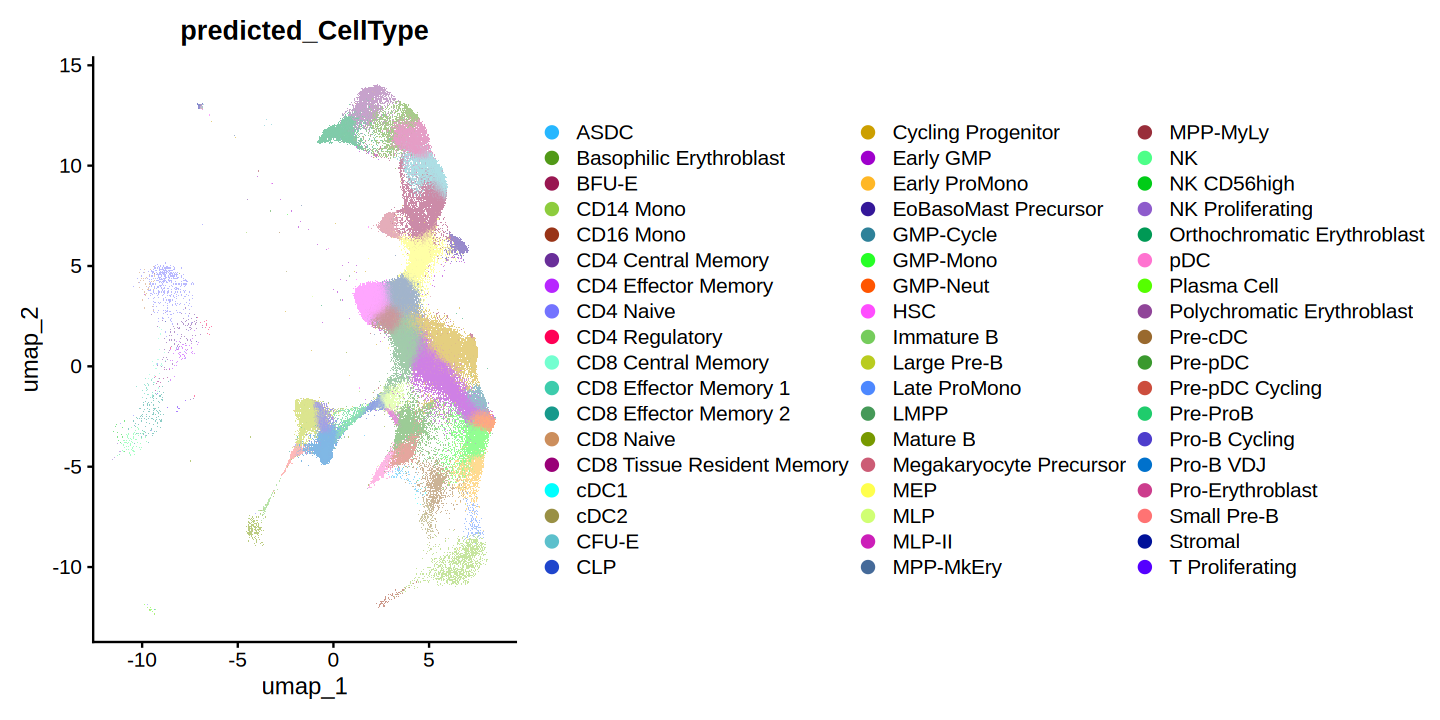

In [4]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=12)
DimPlot_scCustom(sce1, pt.size=0.5,reduction = "umap", group.by = c("predicted_CellType"),label=F) 

In [5]:
celltypes_keep <- c(
  "ASDC",
  "CD14 Mono",
  "CD16 Mono",
  "cDC1","cDC2","Early GMP","Early ProMono","GMP-Cycle","GMP-Mono","GMP-Neut",'HSC',"Late ProMono","LMPP","pDC","Pre-cDC","Pre-pDC","Pre-pDC Cycling"
)

sce1_myeloid <- subset(
  sce1,
  subset = predicted_CellType %in% celltypes_keep
)

## 2. Visualization and figure generation


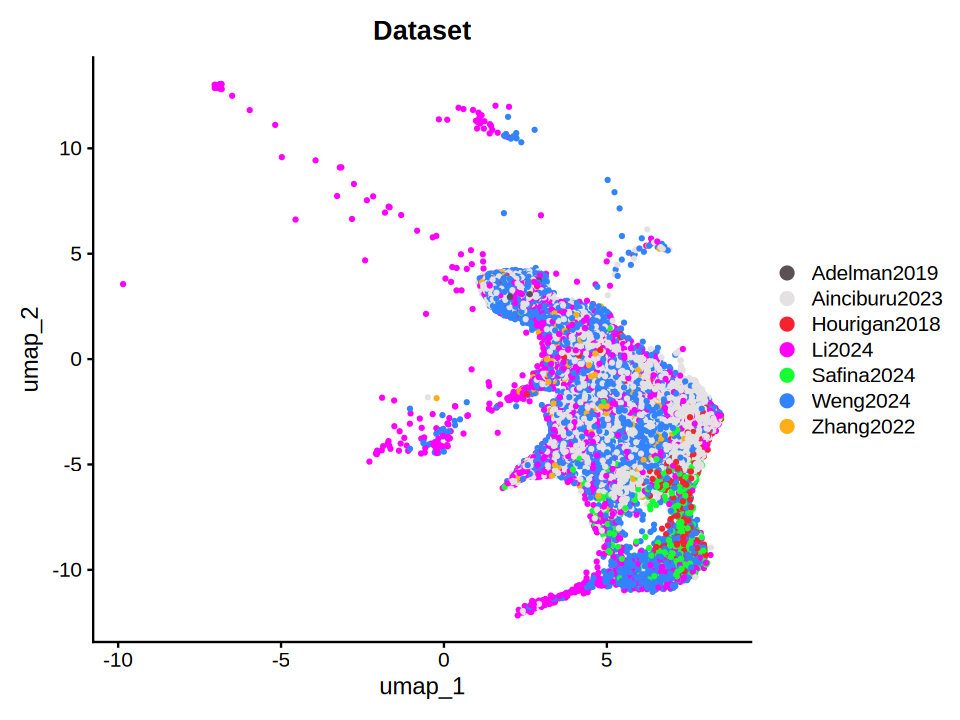

In [6]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_myeloid, pt.size=0.5,reduction = "umap", group.by = c("Dataset"),label=F) 

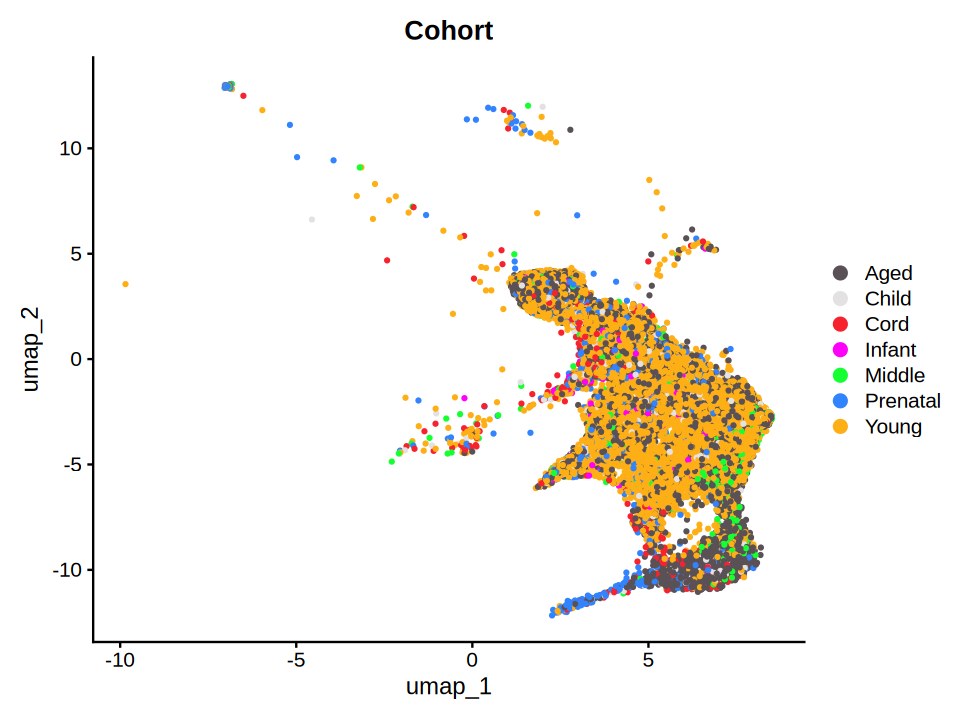

In [7]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_myeloid, pt.size=0.5,reduction = "umap", group.by = c("Cohort"),label=F) 

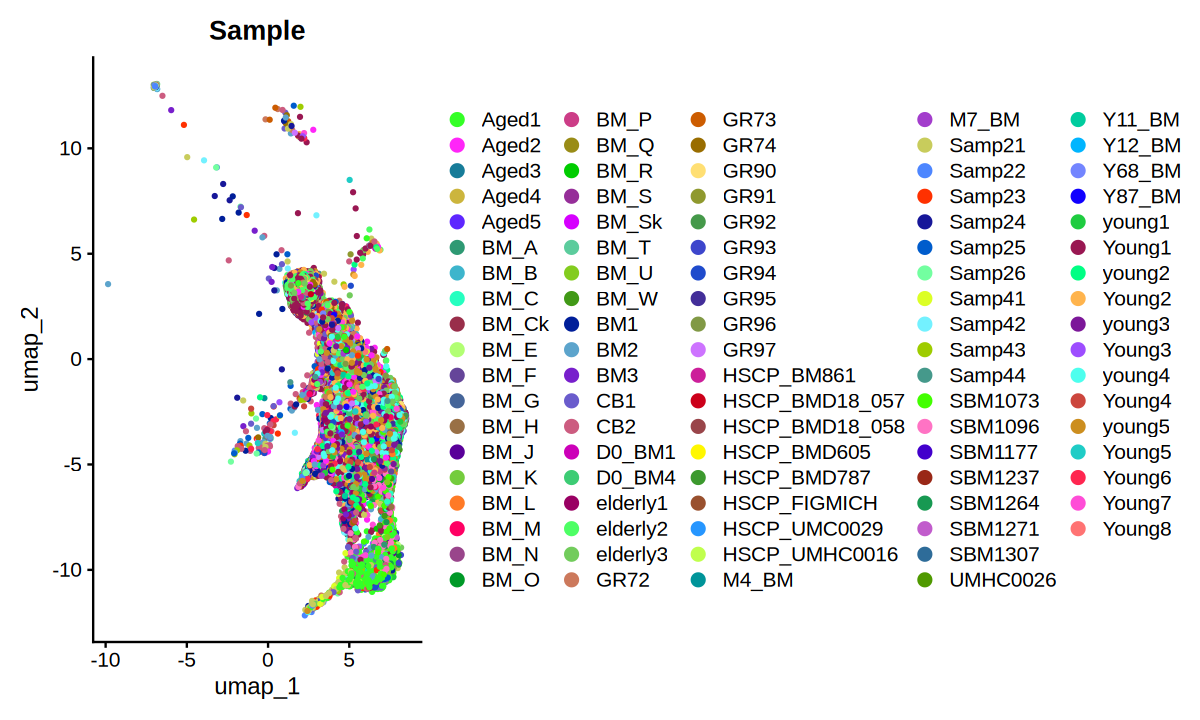

In [8]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=10)
DimPlot_scCustom(sce1_myeloid, pt.size=0.5,reduction = "umap", group.by = c("Sample"),label=F) 

## 3. Your object: must contain raw counts in RNA (default) assay


In [9]:
library(Seurat)
library(Azimuth)

# Your object: must contain raw counts in RNA (default) assay
# e.g., obj <- Read10X("path/to/filtered_feature_bc_matrix/") |> CreateSeuratObject()

# Optional: basic QC/feature calc (doesn't affect Azimuth’s internal normalization)
# obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^MT-")

# Run Azimuth mapping. Reference key for human BM is "bonemarrowref".
bm_anno <- RunAzimuth(
  query     = sce1_myeloid,
  reference = "bonemarrowref"   # Azimuth will fetch the HuBMAP Bone Marrow reference
)

# The returned object is your query with added predictions & projected UMAPs.
bm_anno


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat



Attaching shinyBS

Warning message:
"Overwriting miscellanous data for model"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
detected inputs from HUMAN with id type Gene.name

reference rownames detected HUMAN with id type Gene.name

Normalizing query using reference SCT model

Warning message:
"No layers found matching search pattern provided"
Warning message:
"301 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 2699 features."
Projecting cell embeddings

Finding query neighbors

Finding neighborhoods

Finding anchors

	Found 15875 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
"Feature name

An object of class Seurat 
11661 features across 79734 samples within 3 assays 
Active assay: RNA (11612 features, 0 variable features)
 1 layer present: counts
 2 other assays present: prediction.score.celltype.l2, prediction.score.celltype.l1
 3 dimensional reductions calculated: umap, integrated_dr, ref.umap

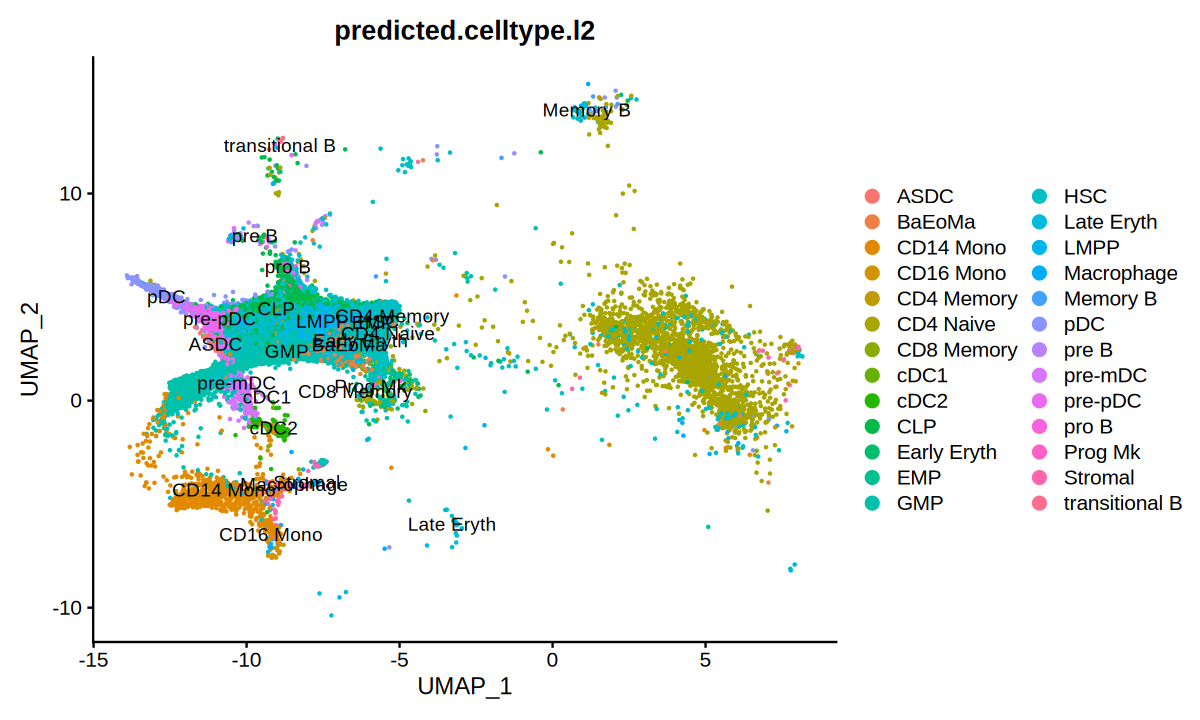

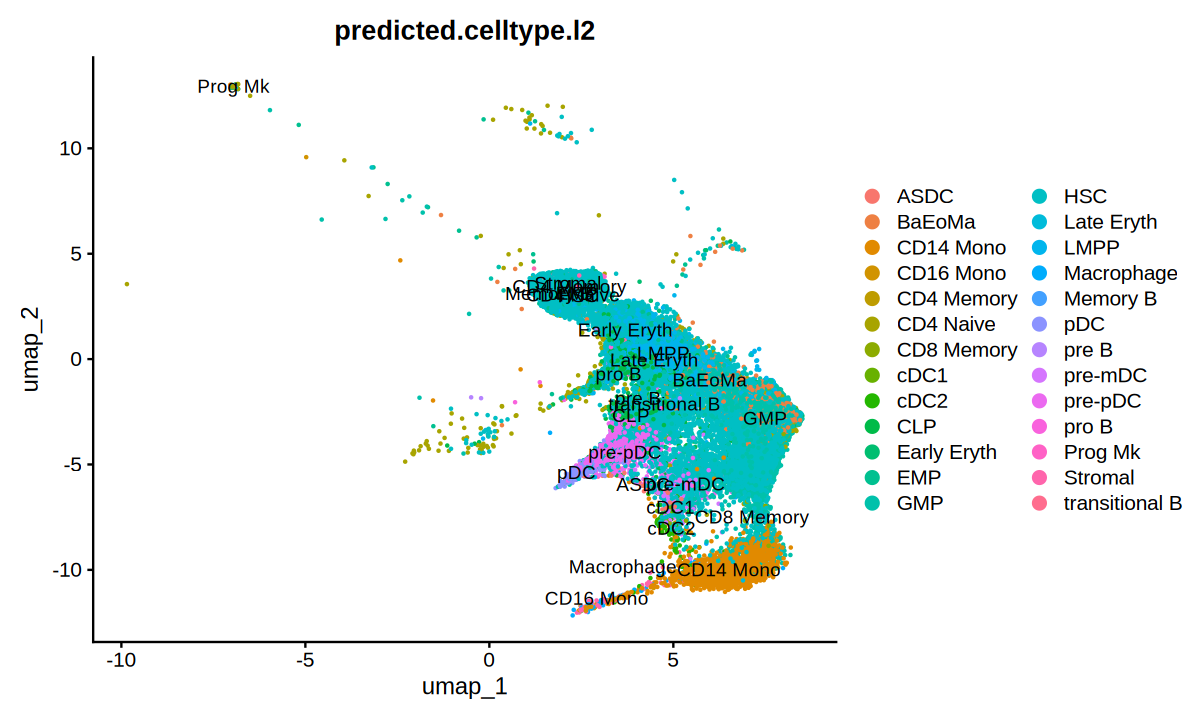

In [10]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

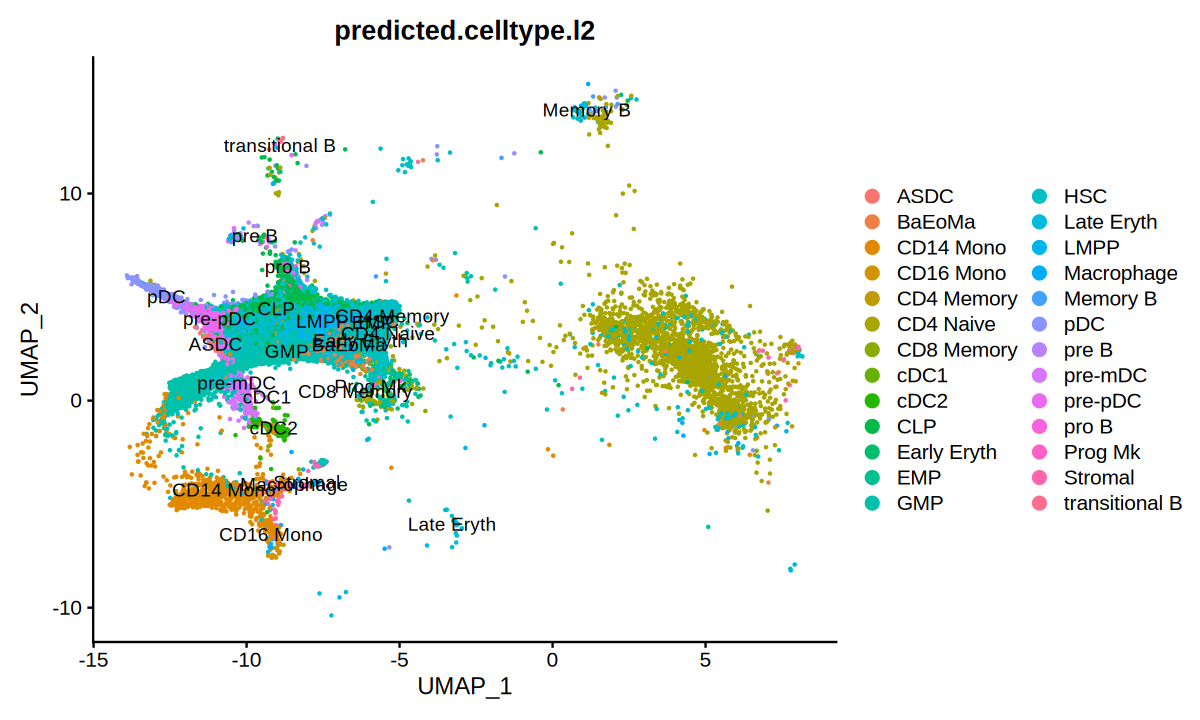

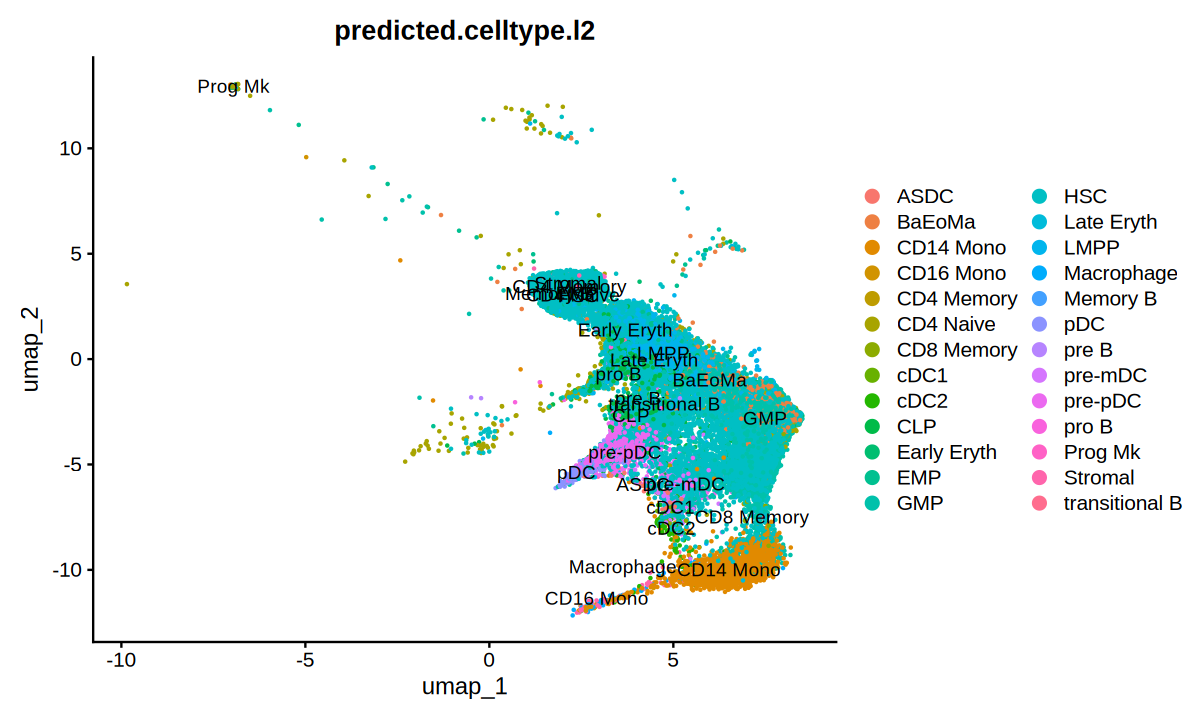

In [11]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

In [12]:
# Flag low-confidence predictions (tune the cutoff for your data)
bm_anno$low_conf <- bm_anno$predicted.celltype.l2.score < 0.5
table(bm_anno$low_conf)

# You can drop or re-cluster low-confidence cells if needed
bm_anno <- subset(bm_anno, subset = predicted.celltype.l2.score >= 0.5)



FALSE  TRUE 
63158 16576 

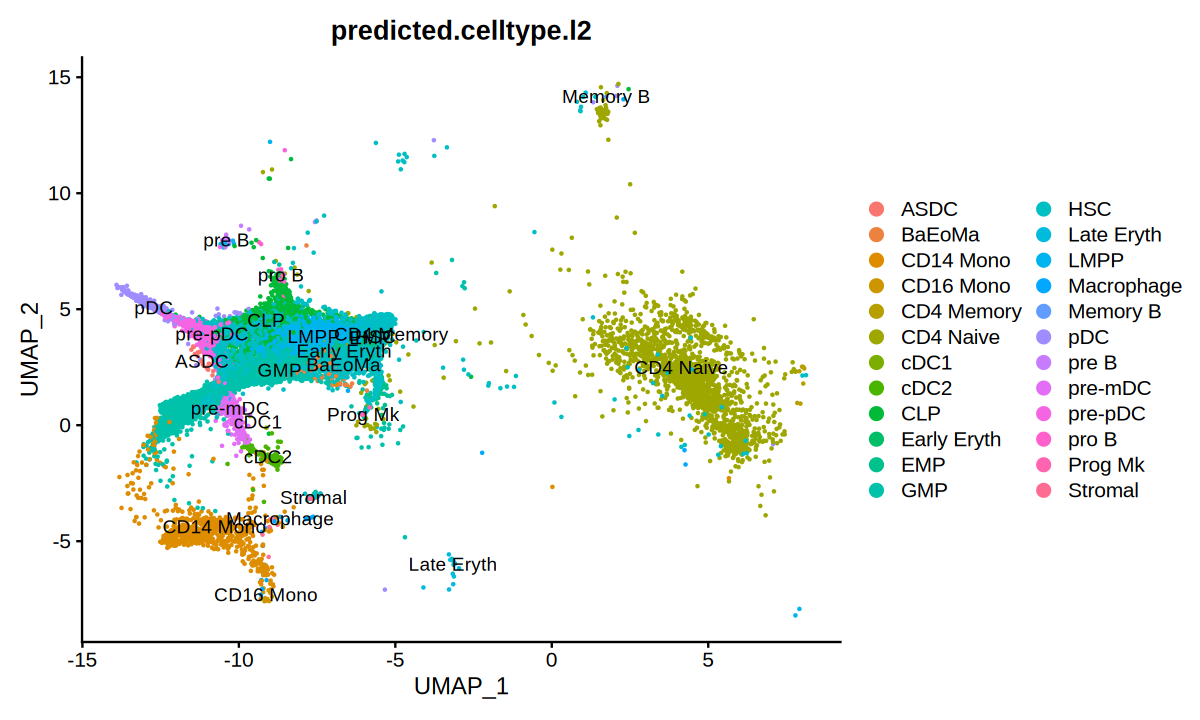

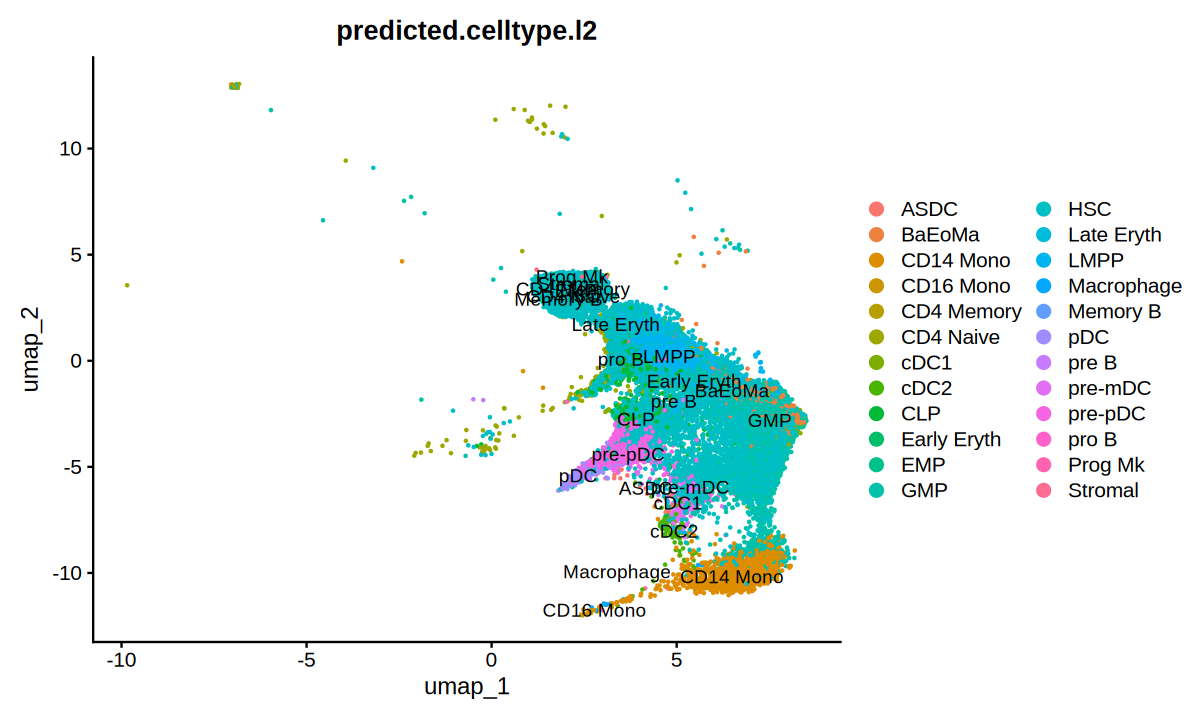

In [13]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

## 4. Cell-type annotation


In [14]:
# 1) Make sure identities are the Azimuth labels (adjust the column name if needed)
Idents(bm_anno) <- "predicted.celltype.l2"

# 2) Define your targets (as a proper character vector)
targets <- c(
  "ASDC","CD14 Mono","CD16 Mono","cDC2","cDC1","LMPP",
  "GMP","HSC","pDC","pre-mDC","pre-pDC","Macrophage"
)

# 3) Compare with what's actually present
available <- levels(Idents(bm_anno))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in Idents(bm_anno).\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message("These requested identities were NOT found and will be skipped: ",
          paste(missing, collapse = ", "))
}

# 4) Subset safely
bm_anno_myeloid <- subset(bm_anno, idents = keep)


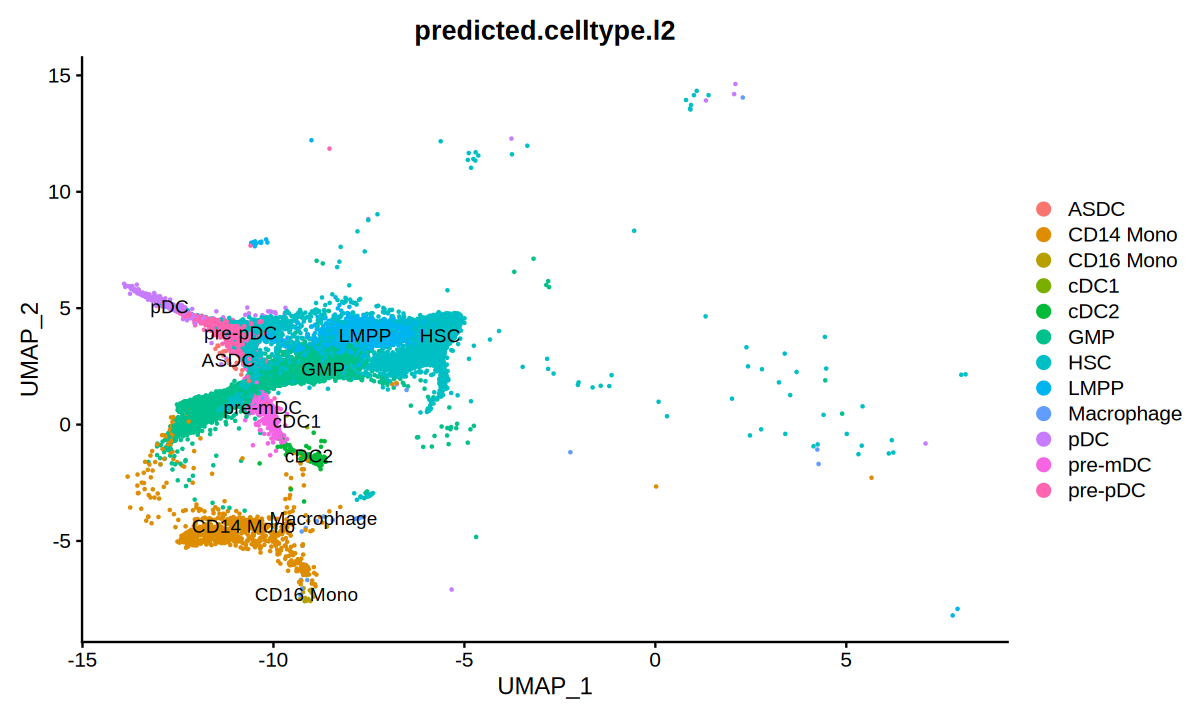

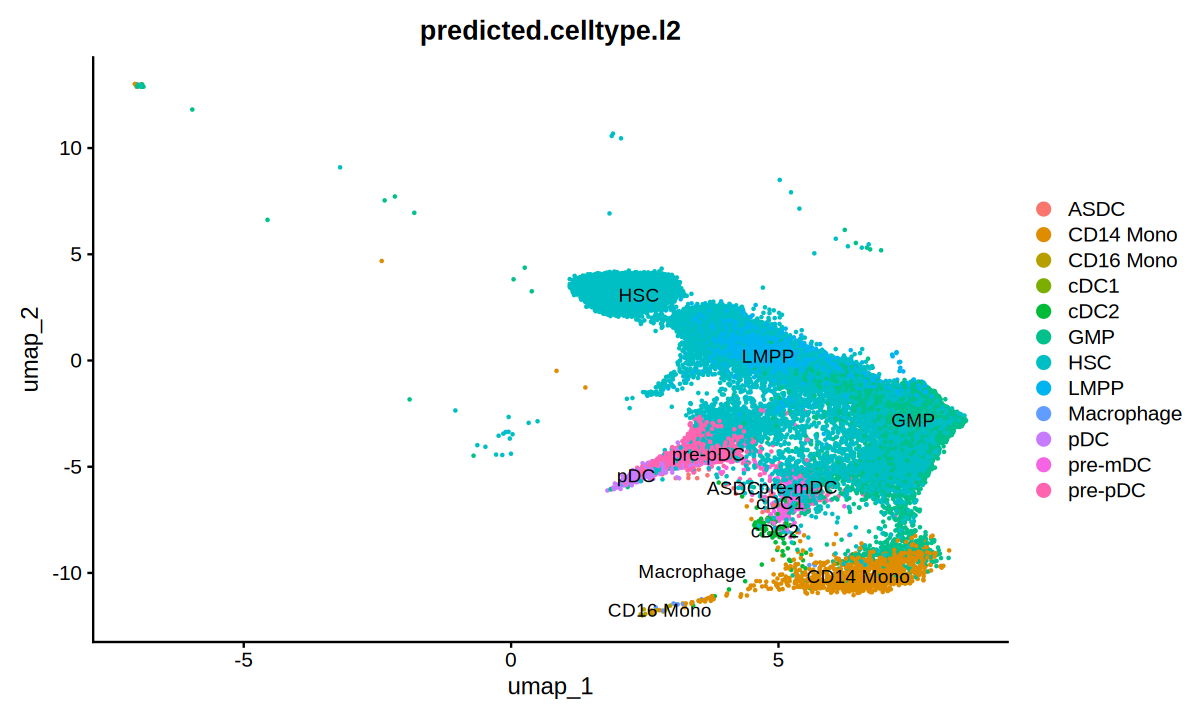

In [15]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno_myeloid, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno_myeloid, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

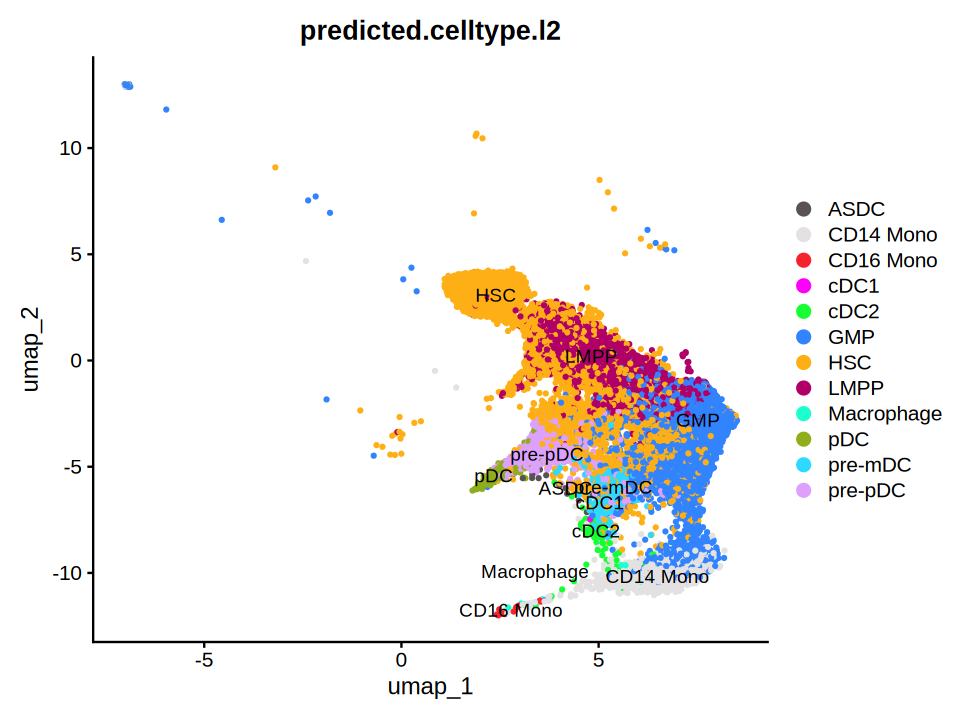

In [16]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("predicted.celltype.l2"),label=T) 

## 5. Packages and setup


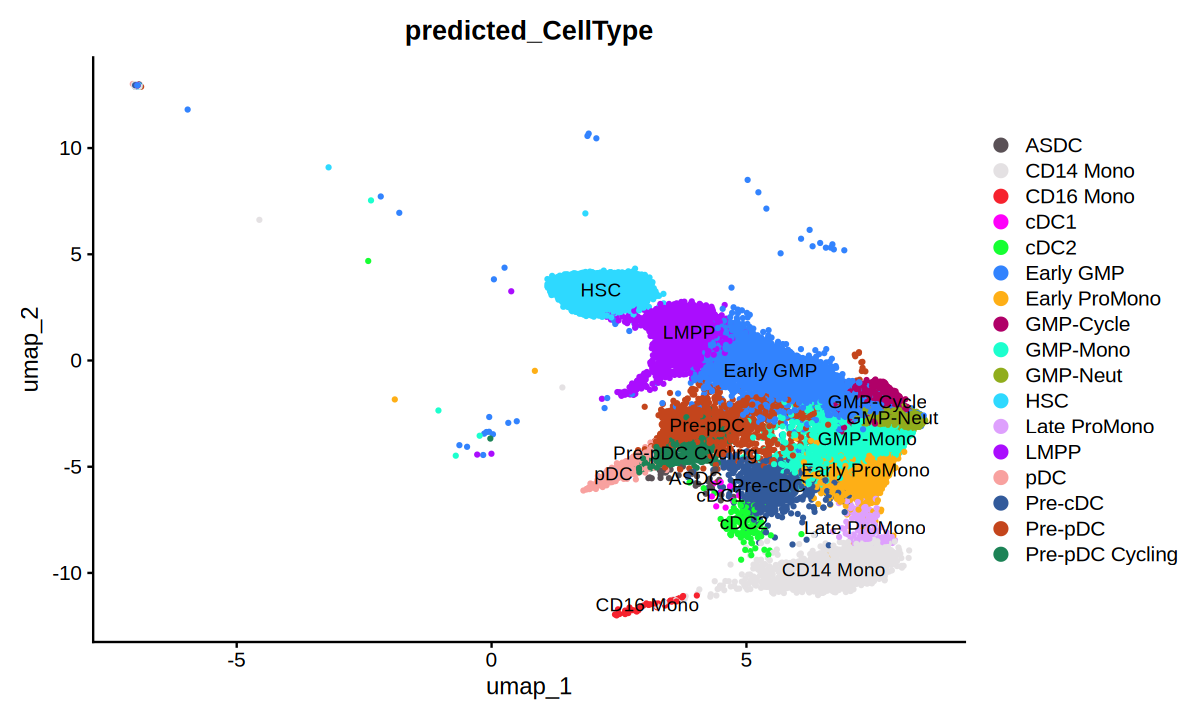

In [17]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=10)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("predicted_CellType"),label=T) 

In [18]:
library(dplyr)

mlab <- as.character(bm_anno_myeloid$predicted.celltype.l2)
lab0 <- as.character(bm_anno_myeloid$predicted_CellType)

final <- case_when(
  !is.na(lab0) & lab0 == "Colony Forming Unit-Monocytes" ~ "Colony Forming Unit-Monocytes",
  !is.na(lab0) & lab0 == "Colony Forming Unit-Granulocytes" ~ "Colony Forming Unit-Granulocytes",
  !is.na(lab0) & lab0 == "Granulocytes (Neutrophils)" ~ "Granulocytes (Neutrophils)",
  TRUE ~ mlab   # default: keep multinomial label
)

# fallback: if final is NA/blamyeloid, use original label
final[is.na(final) | final == ""] <- lab0[is.na(final) | final == ""]

bm_anno_myeloid$final_label <- factor(final, levels = sort(unique(final)))


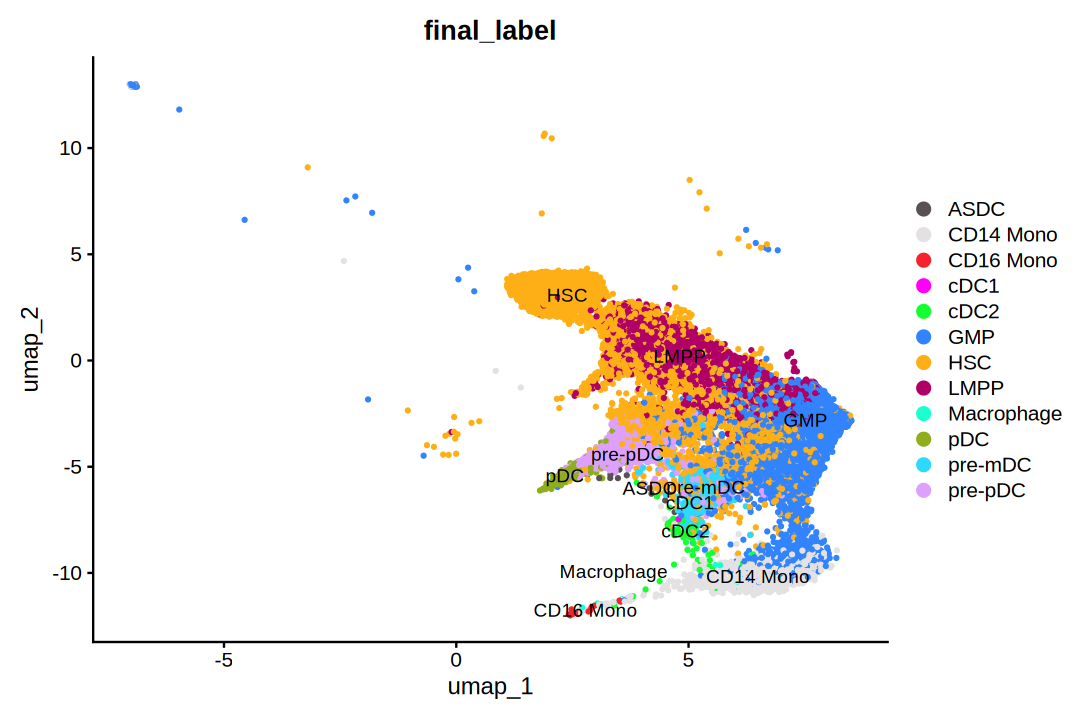

In [19]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("final_label"),label=T) 

In [20]:
Idents(bm_anno_myeloid) <- "final_label"  

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene <- c(
    #HSC
    "CD34",
    # mono/macro
    "VCAN","THBS1","S1PR3","CD36","ALDH1A1","CYP1B1","NRG1",
    # neutrophil
    "CXCR1","CXCR2","FCGR3B","MME","PI3","G0S2",
    # immature
    "MPO","ELANE","PRTN3","AZU1","CTSG","DEFA4","OLR1",
    # mature
    "FCGR3B","MME","CXCR1","CXCR2","CEACAM8",
    # proliferating
    "CDC20","UBE2C","BIRC5","CENPA",
    # kuffer-like?cDC2?
    "CD14","CD163","CLEC10A","NOTCH2","ITGAM","SIRPA","CX3CR1","CD1C",
    # dendritic
    "CD1C","CD1E","FCER1A","CLEC10A","CCR6","NDRG2","PKIB","GRIP1","XCR1",
    # plasmatoid
    "CLEC4C","LILRB4","NRP1",
    "CD38"
)



In [21]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(bm_anno_myeloid, features = unique(allgene), scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
"No layers found matching search pattern provided"
Warning message in FetchData.Assay5(object = object[[DefaultAssay(object = object)]], :
"data layer is not found and counts layer is used"
Warning message:
"The following requested variables were not found (10 out of 21 shown): VCAN, CYP1B1, NRG1, CXCR1, CXCR2, FCGR3B, PI3, G0S2, ELANE, PRTN3"


## 6. Packages and reproducibility setup



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




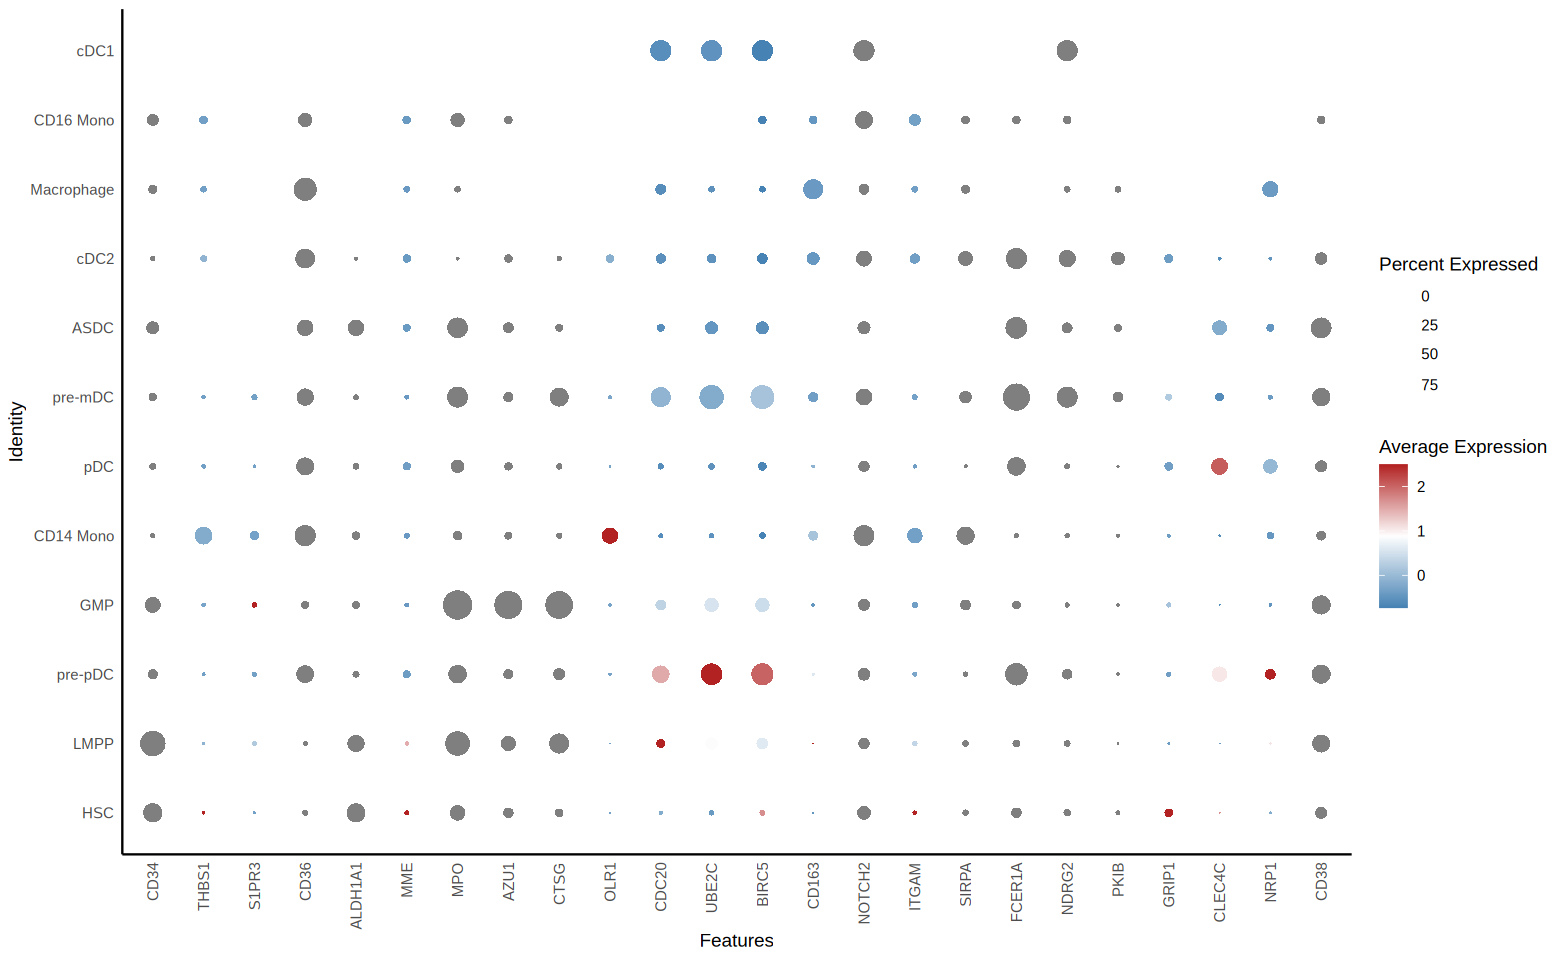

In [22]:
options(repr.plot.height=8,repr.plot.width=13)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [23]:
library(msigdbr)
library(dplyr)
library(readr)

monocytes <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "BP") %>%
  filter(gs_name == "GOBP_MONOCYTE_CHEMOTAXIS") %>%
  distinct(gene_symbol)

neutrophils <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "BP") %>%
  filter(gs_name == "GOBP_NEUTROPHIL_CHEMOTAXIS") %>%
  distinct(gene_symbol)

write_csv(monocytes, "GO_monocyte_chemotaxis_genes_MSigDB.csv")
write_csv(neutrophils,   "GO_neutrophil_chemotaxis_genes_MSigDB.csv")


Loading required package: grid

Loading required package: futile.logger



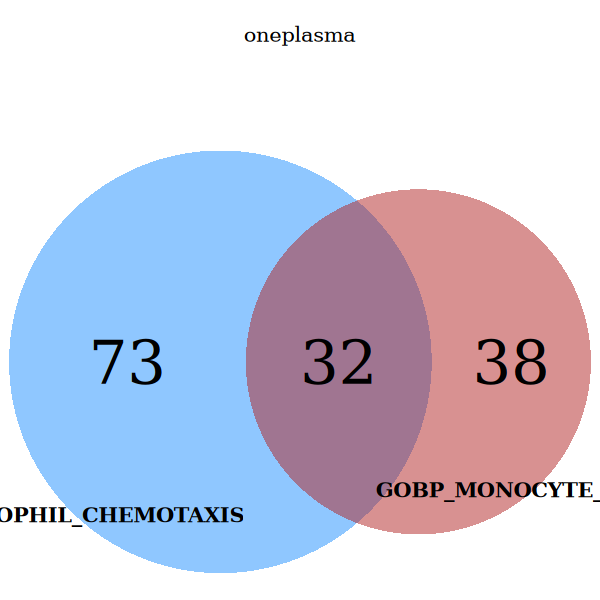

In [24]:
library(VennDiagram)
options(repr.plot.height=5,repr.plot.width=5)
input<-list(monocytes$"gene_symbol",neutrophils$"gene_symbol")
Table<-calculate.overlap(input)
venn<-venn.diagram(main='oneplasma',input,NULL, cat.fontface = "bold",cat.cex = 1,cex = 3,
category = c('GOBP_MONOCYTE_CHEMOTAXIS',"GOBP_NEUTROPHIL_CHEMOTAXIS"),fill = c( "firebrick",'dodgerblue'),lty='blank',
cat.col= 'black',   imagetype = "tiff",  main.fontfamily="serif") #, filename = "Vennup.tif"
grid.draw(venn)

## 7. Inputs


$a1
 [1] "AIF1"         "ANO6"         "ANXA1"        "CALCA"        "CCL1"        
 [6] "CCL11"        "CCL13"        "CCL14"        "CCL15"        "CCL16"       
[11] "CCL17"        "CCL18"        "CCL19"        "CCL2"         "CCL20"       
[16] "CCL21"        "CCL22"        "CCL23"        "CCL24"        "CCL25"       
[21] "CCL26"        "CCL3"         "CCL3L1"       "CCL3L3"       "CCL4"        
[26] "CCL5"         "CCL7"         "CCL8"         "CCN3"         "CCR1"        
[31] "CCR2"         "CREB3"        "CTSG"         "CX3CL1"       "CX3CR1"      
[36] "CXCL10"       "CXCL12"       "CXCL17"       "DEFB104A"     "DEFB104B"    
[41] "DEFB124"      "DUSP1"        "FLT1"         "FOLR2"        "FPR2"        
[46] "GREM1"        "HMGB1"        "IL6"          "IL6R"         "LGALS3"      
[51] "LGMN"         "LYN"          "MICOS10-NBL1" "MOSPD2"       "MSMP"        
[56] "NBL1"         "PDGFB"        "PLA2G7"       "PTPRO"        "RPS19"       
[61] "S100A12"      "S100A14"      "

pdf 
  2

pdf 
  2

Saved: Vennup.tif and Vennup.pdf



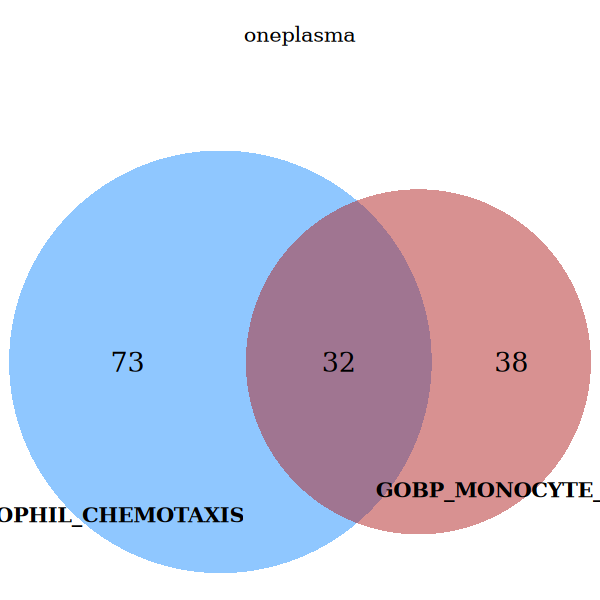

In [25]:
suppressPackageStartupMessages({
  library(VennDiagram)
  library(grid)
})

options(repr.plot.height = 5, repr.plot.width = 5)

# ---------------------------
# Inputs
# ---------------------------
input <- list(
  monocytes   = monocytes$gene_symbol,
  neutrophils = neutrophils$gene_symbol
)

# Optional: remove NAs/duplicates for cleaner counts
input <- lapply(input, function(x) unique(na.omit(x)))

# ---------------------------
# Compute overlap table (if you want it)
# ---------------------------
Table <- calculate.overlap(input)
print(Table)

# ---------------------------
# Draw to the active device (notebook)
# ---------------------------
venn <- venn.diagram(
  x = input,
  filename = NULL,                 # IMPORTANT: render to current device
  main = "oneplasma",
  category.names = c("GOBP_MONOCYTE_CHEMOTAXIS", "GOBP_NEUTROPHIL_CHEMOTAXIS"),
  cat.fontface = "bold",
  cat.cex = 1,
  cex = 1.3,                       # text size inside circles
  fill = c("firebrick", "dodgerblue"),
  lty = "blank",
  cat.col = "black",
  main.fontfamily = "serif"
)

grid.newpage()
grid.draw(venn)

# ---------------------------
# Export as TIFF (recommended for journals)
# ---------------------------
out_tiff <- "Vennup.tif"
tiff(out_tiff, width = 1600, height = 1600, res = 300, compression = "lzw")
grid.newpage()
grid.draw(venn)
dev.off()

# ---------------------------
# (Optional) Export as PDF too
# ---------------------------
out_pdf <- "Vennup.pdf"
pdf(out_pdf, width = 5, height = 5)
grid.newpage()
grid.draw(venn)
dev.off()

message("Saved: ", out_tiff, " and ", out_pdf)


In [26]:
bm_anno_myeloid <- NormalizeData(
  bm_anno_myeloid,
  assay = "RNA",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  verbose = TRUE
)

Layers(bm_anno_myeloid[["RNA"]])

Normalizing layer: counts



[1] "counts" "data"

In [27]:
## ---- 0) Gene sets ----
geneset1 <- monocytes$"gene_symbol"     # mono/macrophage-like
geneset2 <- neutrophils$"gene_symbol"                 # neutrophil-like

## ---- 1) Add scores to the original object ----
# Columns will be Set11 and Set21 in meta.data
bm_anno_myeloid<- AddModuleScore(bm_anno_myeloid, features = list(geneset1), name = "Set1")
bm_anno_myeloid<- AddModuleScore(bm_anno_myeloid, features = list(geneset2), name = "Set2")


Warning message:
"The following features are not present in the object: CALCA, CCL1, CCL11, CCL13, CCL14, CCL15, CCL16, CCL17, CCL18, CCL19, CCL2, CCL20, CCL21, CCL22, CCL23, CCL24, CCL25, CCL26, CCL3L1, CCL3L3, CCL4, CCL7, CCL8, CCN3, CCR1, CCR2, CX3CL1, CX3CR1, CXCL10, CXCL12, CXCL17, DEFB104A, DEFB104B, DEFB124, FOLR2, FPR2, GREM1, IL6, MICOS10-NBL1, MSMP, PDGFB, PLA2G7, PTPRO, S100A12, S100A14, S100A7, SLAMF8, SLIT2, TNFSF11, XCL1, XCL2, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: C3AR1, CCL1, CCL11, CCL13, CCL14, CCL15, CCL16, CCL17, CCL18, CCL19, CCL2, CCL20, CCL21, CCL22, CCL23, CCL24, CCL25, CCL26, CCL3L1, CCL3L3, CCL4, CCL7, CCL8, CD300H, CX3CL1, CXCL1, CXCL10, CXCL11, CXCL13, CXCL5, CXCL6, CXCL9, CXCR1, CXCR2, DPP4, EDN1, EDN2, EDN3, IL23A, LBP, MIR223, PF4, PF4V1, PLA2G1B, PPBP, RIPOR2, S100A12, S100A9, SAA1, SLIT2, TGFB2, TNFAIP6, TREM1, XCL1, XCL2, not searching for symbol synonyms"


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=41.8%' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=41.8%' in 'mbcsToSbcs': dot substituted for <86>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=41.8%' in 'mbcsToSbcs': dot substituted for <92>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=41.8%' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=41.8%' in 'mbcsToSbcs': dot substituted for <86>"
Warning message in grid.Call.graphics(C

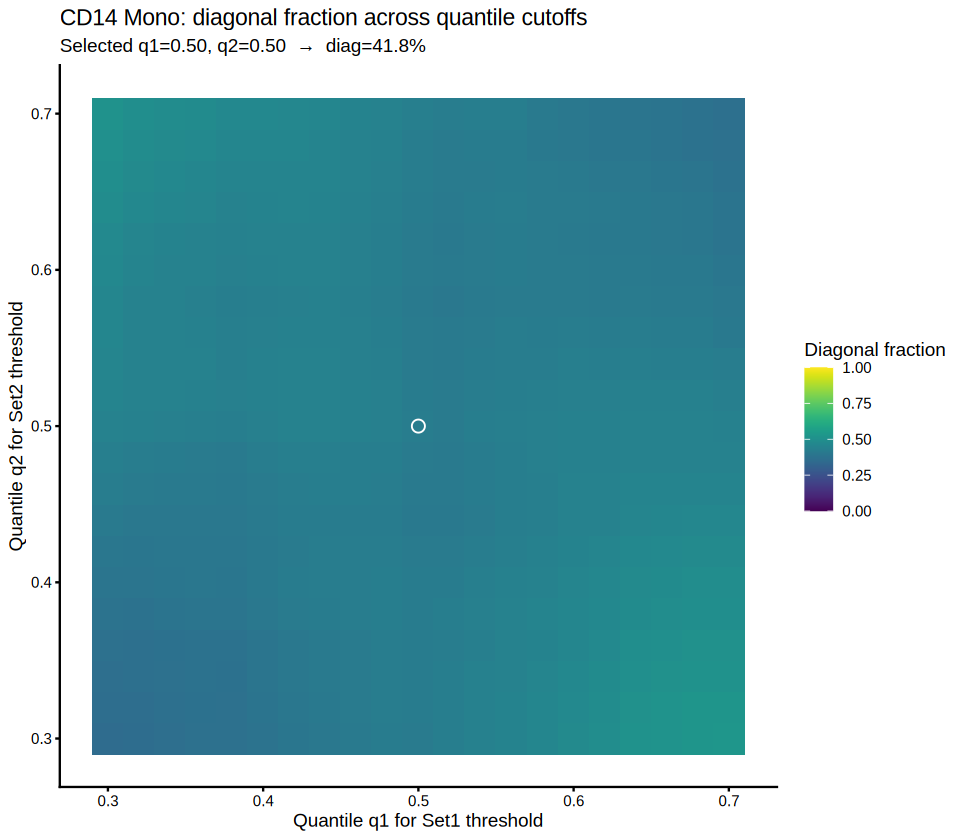

Final (per-set) diagonal fraction in CD14 Mono: 41.8%




set1High_set2High  set1High_set2Low  set1Low_set2High   set1Low_set2Low 
              280               201               201               280 


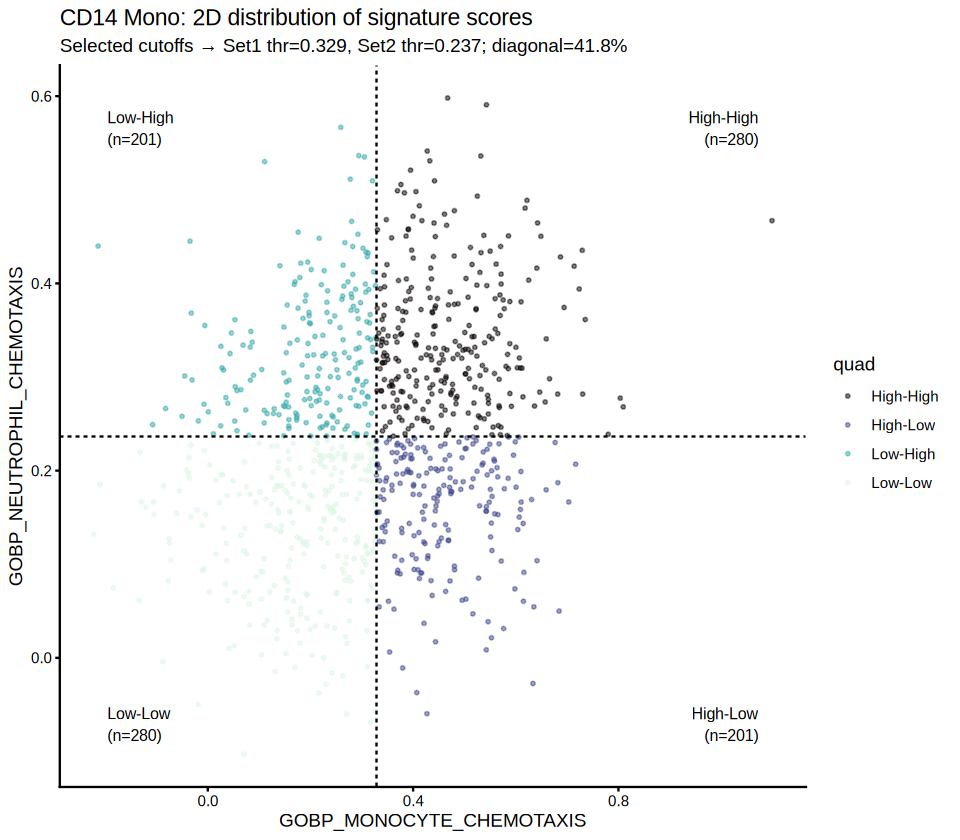

In [28]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(viridis)
  library(purrr)
})

options(repr.plot.height=7, repr.plot.width=8)

# ======================== CONFIG =========================
anno_col   <- "final_label"
cell_type  <- "CD14 Mono"
MODE       <- "maximize"   # "maximize" or "enforce"
TARGET     <- 0.60         # used when MODE == "enforce" (min diagonal fraction)
USE_DIFF_MODE <- TRUE      # also try the |Set1-Set2| gap method

# ==================== PREPARE DATA =======================
is_ct <- bm_anno_myeloid@meta.data[[anno_col]] == cell_type

df <- bm_anno_myeloid@meta.data %>%
  tibble::as_tibble(rownames = "cell") %>%
  filter(.data[[anno_col]] == !!cell_type) %>%
  transmute(cell,
            set1 = Set11,
            set2 = Set21) %>%
  filter(is.finite(set1), is.finite(set2))

stopifnot(nrow(df) > 0)

use_hex <- nrow(df) > 20000

# Helper: compute diagonal fraction for given numeric thresholds
diag_prop_from_thresholds <- function(s1, s2, thr1, thr2) {
  lab1 <- ifelse(s1 >= thr1, "set1High", "set1Low")
  lab2 <- ifelse(s2 >= thr2, "set2High", "set2Low")
  mean((lab1 == "set1High" & lab2 == "set2Low") |
       (lab1 == "set1Low"  & lab2 == "set2High"),
       na.rm = TRUE)
}

# ================== GRID OVER QUANTILES ==================
s1 <- df$set1; s2 <- df$set2
q_grid1 <- seq(0.30, 0.70, by = 0.02)
q_grid2 <- seq(0.30, 0.70, by = 0.02)

grid_tbl <- tidyr::crossing(q1 = q_grid1, q2 = q_grid2) %>%
  mutate(
    thr1 = as.numeric(map_dbl(q1, ~ quantile(s1, .x, na.rm = TRUE))),
    thr2 = as.numeric(map_dbl(q2, ~ quantile(s2, .x, na.rm = TRUE))),
    prop_diag = pmap_dbl(list(thr1, thr2), ~ diag_prop_from_thresholds(s1, s2, ..1, ..2)),
    dist_to_med = abs(q1 - 0.5) + abs(q2 - 0.5)  # used for tie-breakers / "enforce"
  )

# ======== FORCE MEDIAN CUTOFFS ON X & Y (Set1, Set2) ========
thr1 <- median(s1, na.rm = TRUE)
thr2 <- median(s2, na.rm = TRUE)
prop_diag_q <- diag_prop_from_thresholds(s1, s2, thr1, thr2)

# keep a fake "best_row" at q1=q2=0.5 so the heatmap still shows a white dot at the median
best_row <- tibble::tibble(
  q1 = 0.50, q2 = 0.50,
  thr1 = thr1, thr2 = thr2,
  prop_diag = prop_diag_q,
  dist_to_med = 0
)


# ============== HEATMAP of diagonal proportion ===========
p_heat <- ggplot(grid_tbl, aes(q1, q2, fill = prop_diag)) +
  geom_tile() +
  scale_fill_viridis(name = "Diagonal fraction", limits = c(0,1)) +
  geom_point(data = best_row, aes(q1, q2), color = "white", size = 3, shape = 21, stroke = 0.6) +
  labs(x = "Quantile q1 for Set1 threshold",
       y = "Quantile q2 for Set2 threshold",
       title = paste0(cell_type, ": diagonal fraction across quantile cutoffs"),
       subtitle = sprintf("Selected q1=%.2f, q2=%.2f  →  diag=%.1f%%",
                          best_row$q1, best_row$q2, 100*prop_diag_q)) +
  theme_classic()

# ============== SCATTER/HEX with chosen thresholds ==========
# Quadrant labeling for the chosen thr1, thr2
df_quads <- df %>%
  mutate(
    quad = case_when(
      set1 >= thr1 & set2 >= thr2 ~ "High-High",
      set1 >= thr1 & set2 <  thr2 ~ "High-Low",
      set1 <  thr1 & set2 >= thr2 ~ "Low-High",
      TRUE                        ~ "Low-Low"
    )
  )

qcounts <- df_quads %>%
  count(quad) %>%
  tidyr::complete(quad = c("High-High","High-Low","Low-High","Low-Low"), fill = list(n = 0))

padx <- (max(df$set1, na.rm=TRUE) - min(df$set1, na.rm=TRUE)) * 0.02
pady <- (max(df$set2, na.rm=TRUE) - min(df$set2, na.rm=TRUE)) * 0.02

labpos <- tibble::tibble(
  quad = c("High-High","High-Low","Low-High","Low-Low"),
  x = c(max(df$set1, na.rm=TRUE) - padx, max(df$set1, na.rm=TRUE) - padx,
        min(df$set1, na.rm=TRUE) + padx, min(df$set1, na.rm=TRUE) + padx),
  y = c(max(df$set2, na.rm=TRUE) - pady, min(df$set2, na.rm=TRUE) + pady,
        max(df$set2, na.rm=TRUE) - pady, min(df$set2, na.rm=TRUE) + pady),
  hjust = c(1,1,0,0),
  vjust = c(1,0,1,0)
) %>% left_join(qcounts, by = "quad") %>%
  mutate(label = paste0(quad, "\n(n=", n, ")"))

p_scatter <- ggplot(df_quads, aes(x = set1, y = set2)) +
  { if (use_hex) geom_hex(bins = 50, alpha = 0.9) else
      geom_point(aes(color = quad), alpha = 0.5, size = 0.6) } +
  geom_vline(xintercept = thr1, linetype = "dashed") +
  geom_hline(yintercept = thr2, linetype = "dashed") +
  labs(x = "GOBP_MONOCYTE_CHEMOTAXIS", y = "GOBP_NEUTROPHIL_CHEMOTAXIS",
       title = paste0(cell_type, ": 2D distribution of signature scores"),
       subtitle = sprintf("Selected cutoffs → Set1 thr=%.3f, Set2 thr=%.3f; diagonal=%.1f%%",
                          thr1, thr2, 100*prop_diag_q)) +
  theme_classic() +
  { if (use_hex) scale_fill_viridis_c(option = "mako") else
      scale_color_viridis_d(option = "mako") } +
  geom_text(data = labpos, aes(x = x, y = y, label = label, hjust = hjust, vjust = vjust),
            size = 3.2)


# ================== PRINT / SAVE ==================
print(p_heat)
print(p_scatter)

# ================== WRITE TAGS BACK (optional) =================
# Use the selected per-set thresholds (q1,q2) for labeling
grp1_all <- ifelse(bm_anno_myeloid@meta.data$Set11 >= thr1, "set1High", "set1Low")
grp2_all <- ifelse(bm_anno_myeloid@meta.data$Set21 >= thr2, "set2High", "set2Low")

orig_lab <- as.character(bm_anno_myeloid@meta.data[[anno_col]])
tag_lab  <- ifelse(bm_anno_myeloid@meta.data[[anno_col]] == cell_type,
                   paste0(cell_type, "_", grp1_all, "_", grp2_all),
                   orig_lab)

bm_anno_myeloid$CD14_tag <- NA_character_
bm_anno_myeloid$CD14_tag[is_ct] <- paste0(grp1_all[is_ct], "_", grp2_all[is_ct])
bm_anno_myeloid$Annotation <- tag_lab

# Quick sanity checks
tab_cd14 <- table(bm_anno_myeloid$CD14_tag[is_ct], useNA = "ifany")
diag_prop_final <- sum(tab_cd14[c("set1High_set2Low","set1Low_set2High")], na.rm = TRUE) / sum(tab_cd14)
message(sprintf("Final (per-set) diagonal fraction in %s: %.1f%%", cell_type, 100*diag_prop_final))
print(tab_cd14)



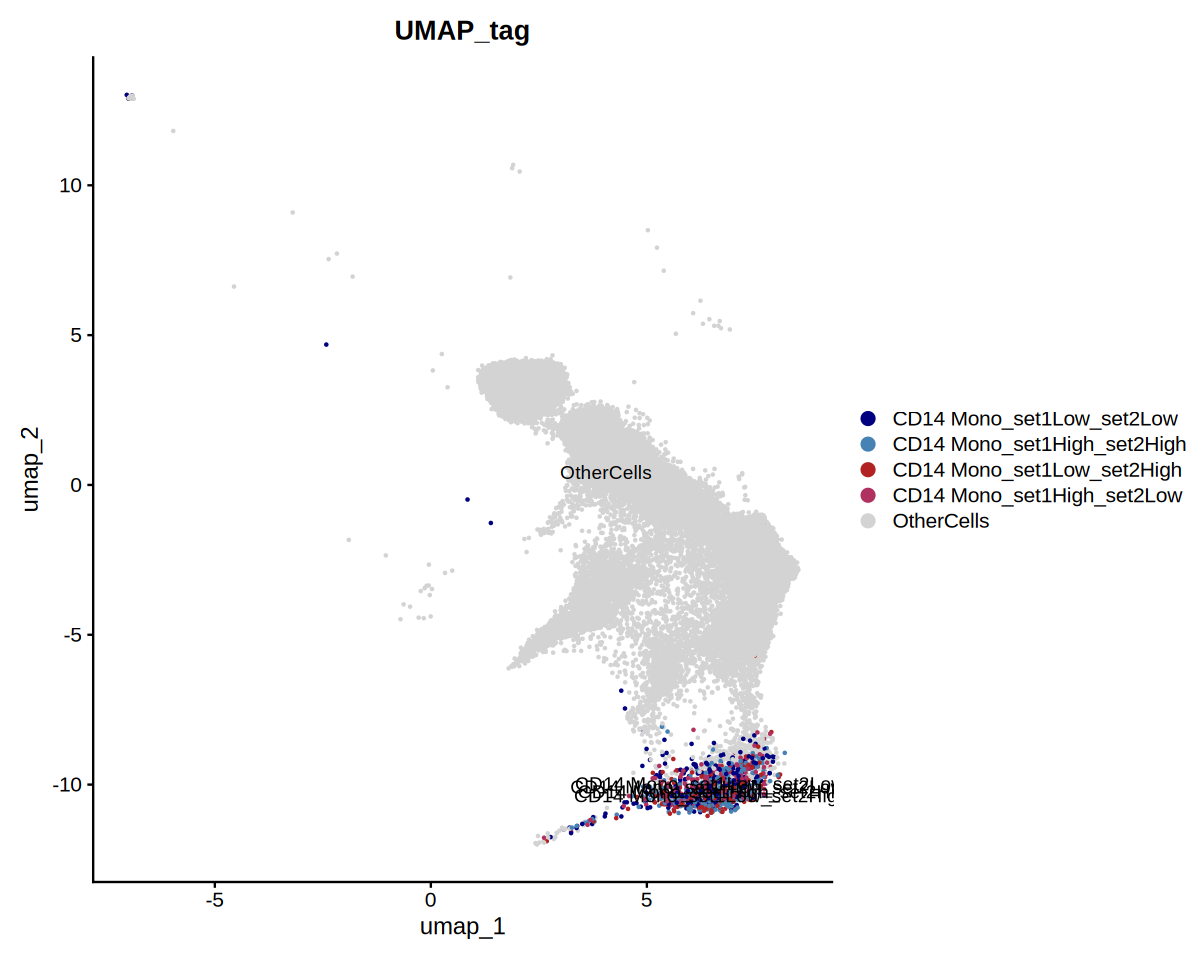

In [29]:
options(repr.plot.height = 8, repr.plot.width = 10)

# 1) Collapse non-CD14 to one label
bm_anno_myeloid$UMAP_tag <- ifelse(
  grepl("^CD14 Mono", bm_anno_myeloid$Annotation),
  bm_anno_myeloid$Annotation,
  "OtherCells"
)

# 2) Get CD14 Mono levels in a stable order
labs        <- unique(bm_anno_myeloid$UMAP_tag)
tag_levels  <- grep("^CD14 Mono", labs, value = TRUE)

# 3) Build the requested color panel for tagged groups
base_panel  <- c("navy", "steelblue", "firebrick", "maroon")
tag_cols    <- base_panel[seq_len(min(length(tag_levels), length(base_panel)))]

# If more CD14 groups than colors, recycle (or swap to a longer panel as needed)
if (length(tag_levels) > length(tag_cols)) {
  tag_cols <- rep(base_panel, length.out = length(tag_levels))
}

# 4) Set plotting order: all CD14 groups first, then "OtherCells"
bm_anno_myeloid$UMAP_tag <- factor(
  bm_anno_myeloid$UMAP_tag,
  levels = c(tag_levels, "OtherCells")
)

# 5) Final palette (OtherCells = lightgrey)
plot_cols <- c(tag_cols, "lightgrey")

# 6) Plot
DimPlot(
  bm_anno_myeloid,
  group.by  = "UMAP_tag",
  reduction = "umap",
  cols      = plot_cols,
  label     = TRUE
)


## 8. Visualization and figure generation


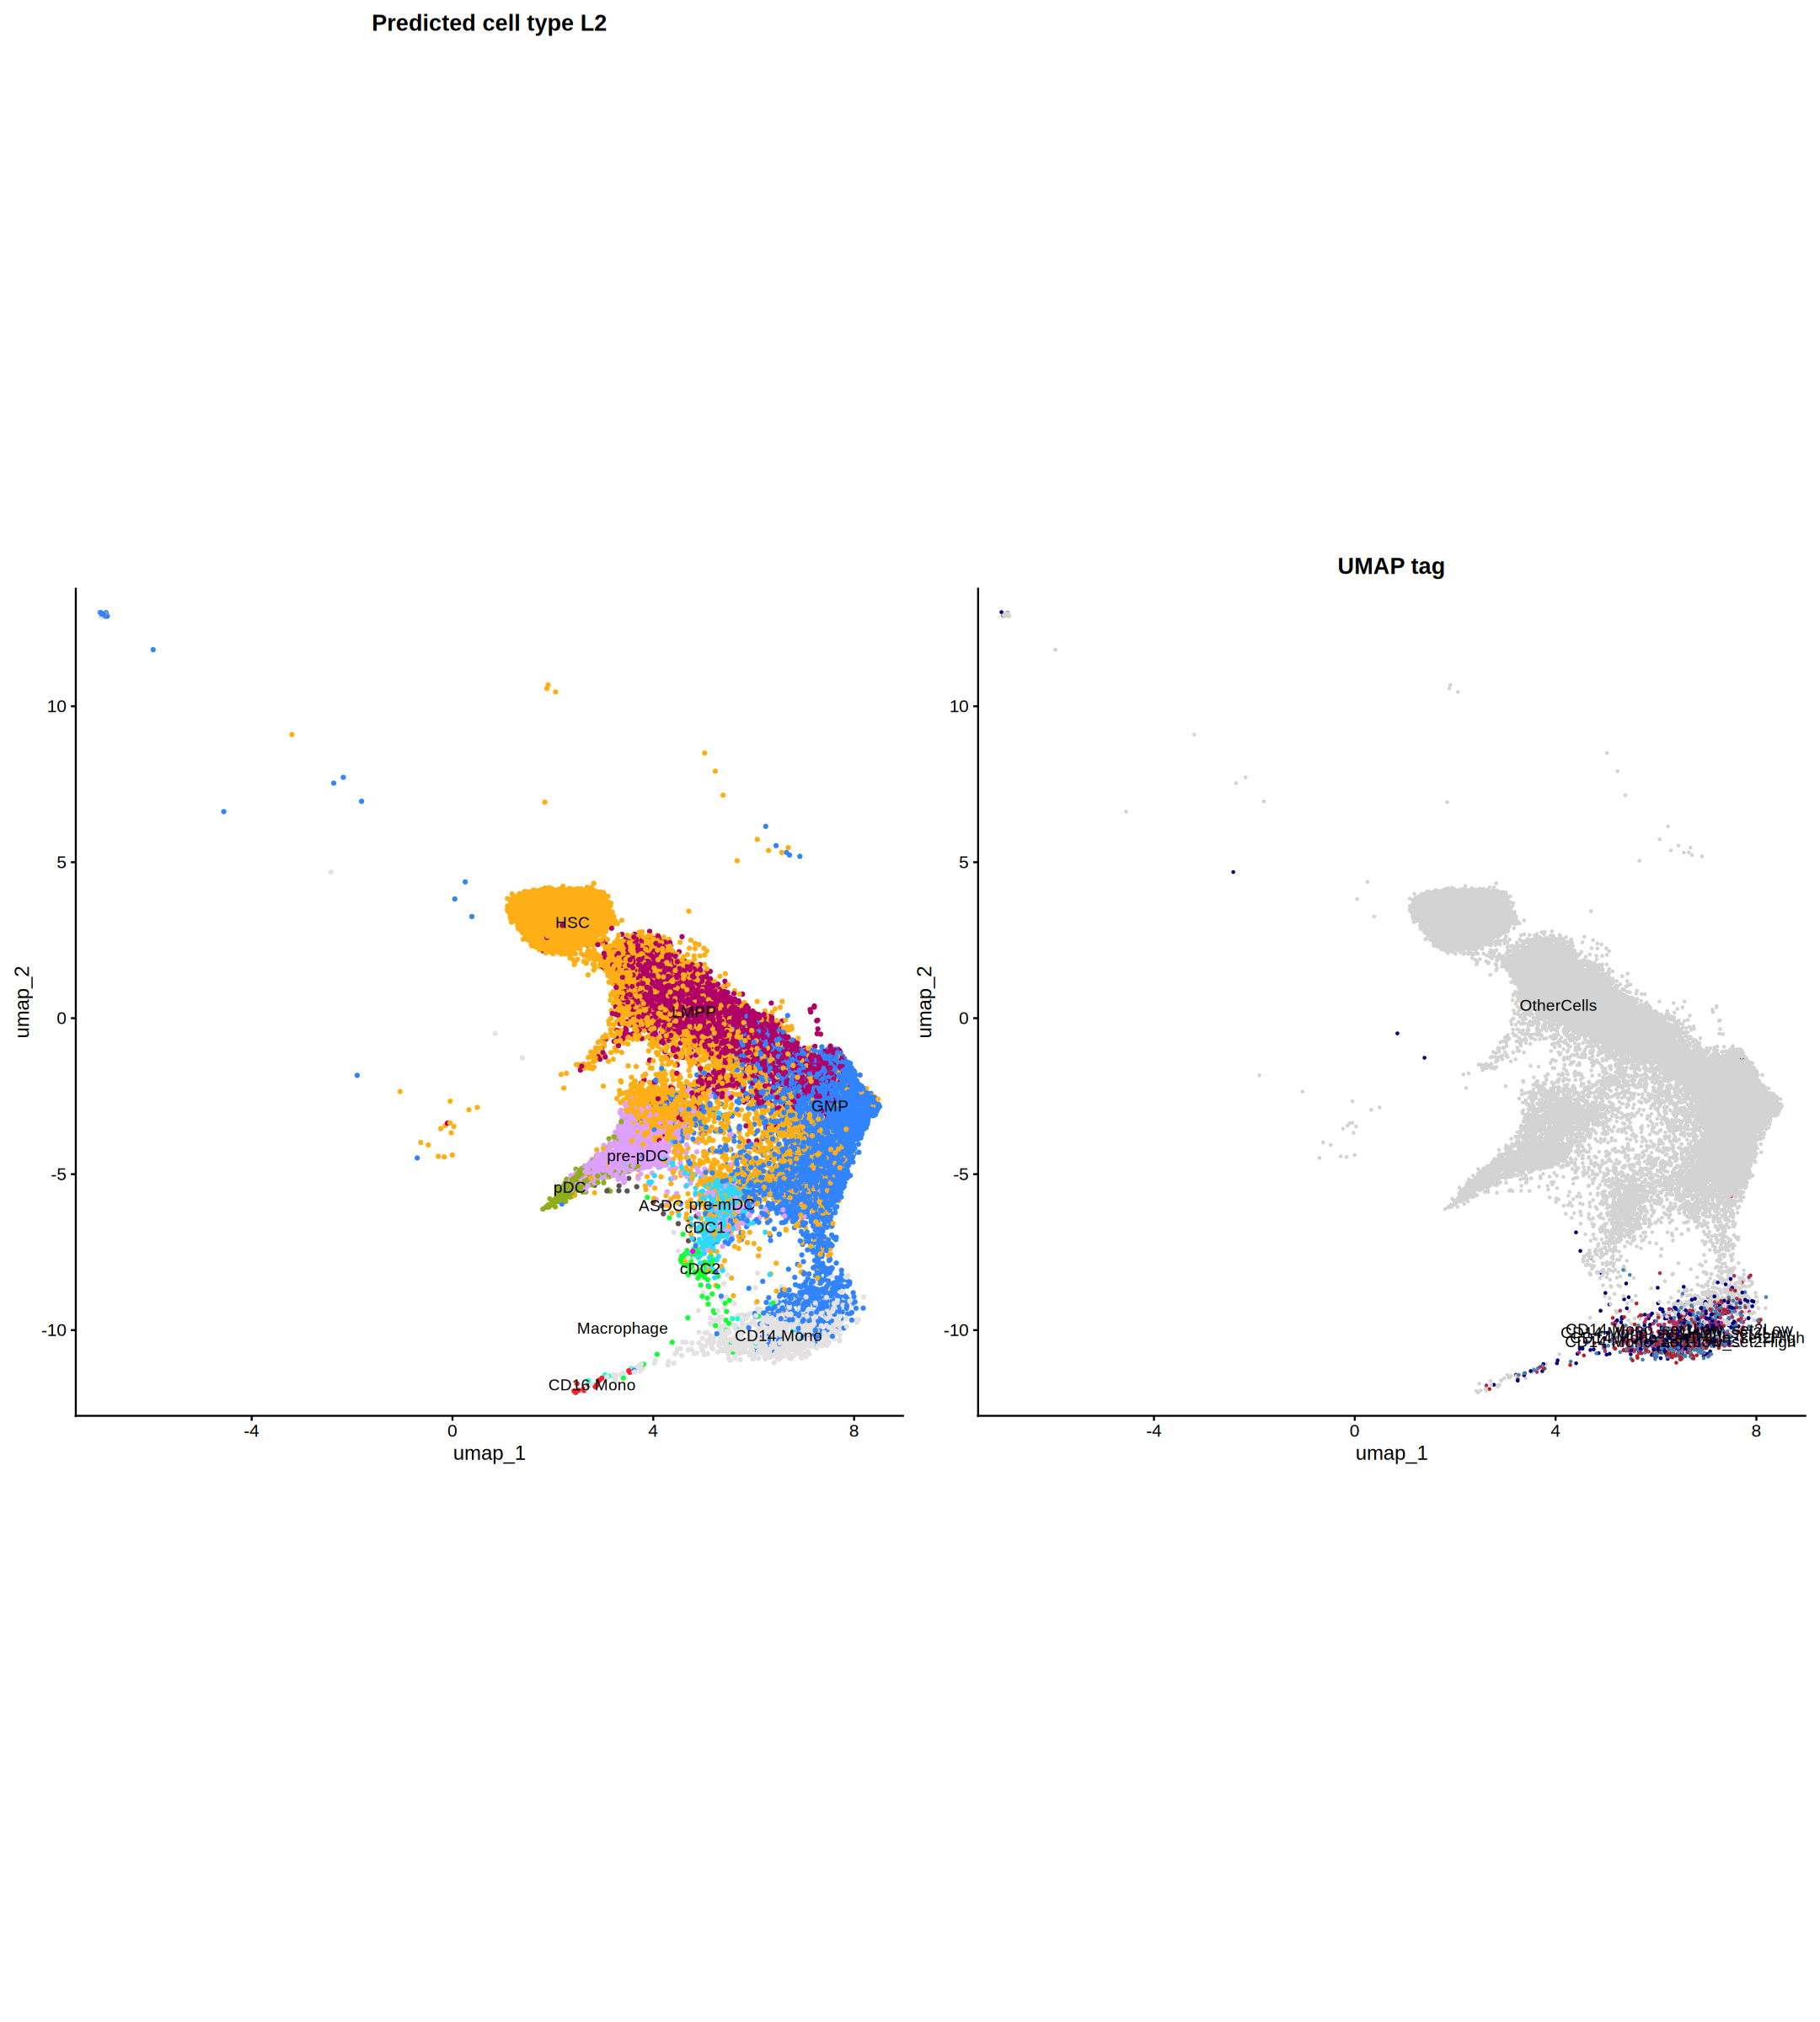

In [41]:
library(Seurat)
library(scCustomize)
library(patchwork)
library(ggplot2)

# Same UMAP coordinate limits for both plots
umap_mat <- Embeddings(bm_anno_myeloid, reduction = "umap")

xlim_use <- range(umap_mat[, 1], na.rm = TRUE)
ylim_use <- range(umap_mat[, 2], na.rm = TRUE)

# Optional small padding
xpad <- diff(xlim_use) * 0.03
ypad <- diff(ylim_use) * 0.03

xlim_use <- xlim_use + c(-xpad, xpad)
ylim_use <- ylim_use + c(-ypad, ypad)

# Shared UMAP theme
umap_theme <- theme(
  aspect.ratio = 1,
  plot.title = element_text(hjust = 0.5, face = "bold"),
  plot.margin = margin(5, 5, 5, 5)
)

p1 <- DimPlot_scCustom(
  bm_anno_myeloid,
  pt.size   = 0.5,
  reduction = "umap",
  group.by  = "predicted.celltype.l2",
  label     = TRUE
) +
  NoLegend() +
  coord_cartesian(xlim = xlim_use, ylim = ylim_use, expand = FALSE) +
  ggtitle("Predicted cell type L2") +
  umap_theme

p2 <- DimPlot(
  bm_anno_myeloid,
  group.by  = "UMAP_tag",
  reduction = "umap",
  cols      = plot_cols,
  label     = TRUE
) +
  NoLegend() +
  coord_cartesian(xlim = xlim_use, ylim = ylim_use, expand = FALSE) +
  ggtitle("UMAP tag") +
  umap_theme

p_combined <- p1 + p2 +
  plot_layout(ncol = 2, widths = c(1, 1))

ggsave(
  filename = "bm_anno_myeloid_umap_panels_same_size.pdf",
  plot     = p_combined,
  width    = 12,
  height   = 6,
  units    = "in",
  device   = cairo_pdf
)

p_combined

In [32]:
# 2) Define your targets (as a proper character vector)
targets <- c("CD14 Mono","CD16 Mono","ASDC","cDC1","cDC2",'Macrophage',"pDC","pre-mDC","pre-pDC")

Idents(bm_anno_myeloid)<-'final_label'

# 3) Compare with what's actually present
available <- levels(Idents(bm_anno_myeloid))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in Idents(bm_anno).\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message("These requested identities were NOT found and will be skipped: ",
          paste(missing, collapse = ", "))
}

# 4) Subset safely
sce1_monodc <- subset(bm_anno_myeloid, idents = keep)


These requested genes were NOT found and will be skipped: CD14

Warning message:
"Scaling data with a low number of groups may produce misleading results"
Warning message:
"Scaling data with a low number of groups may produce misleading results"


pdf 
  2

Saved PDF: myeloid_DC_dotplot_split_and_nonsplit.pdf



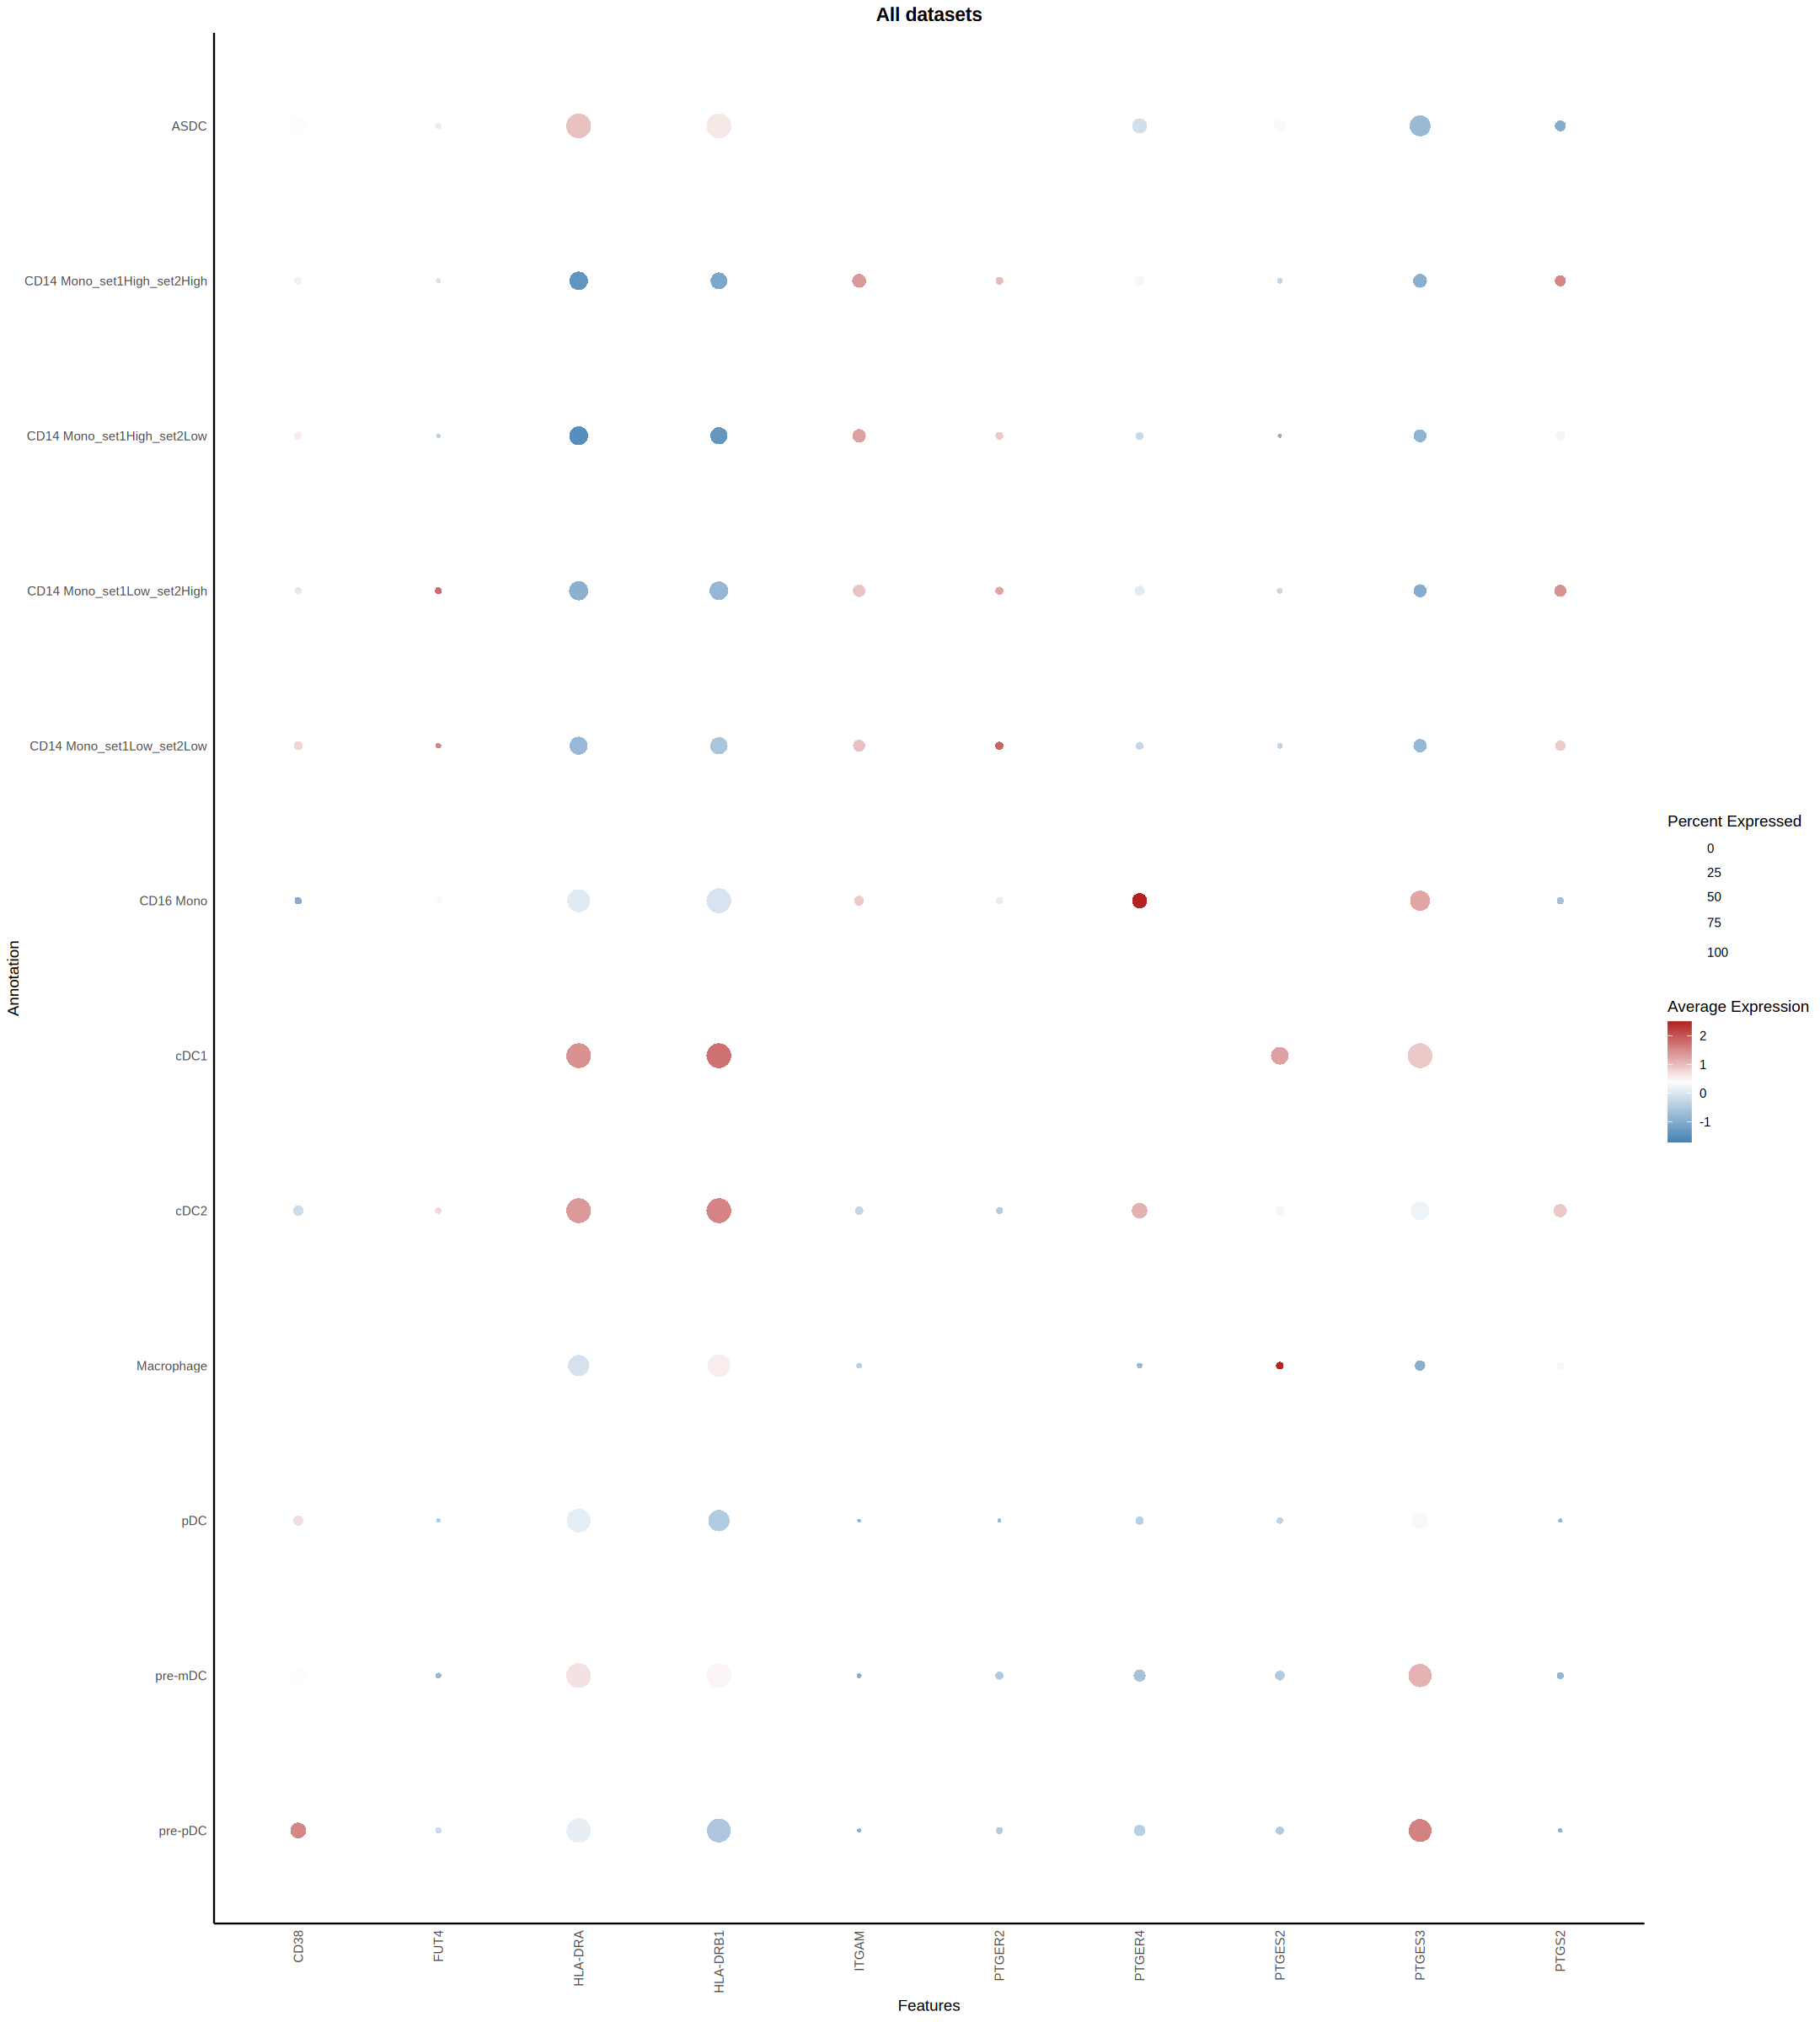

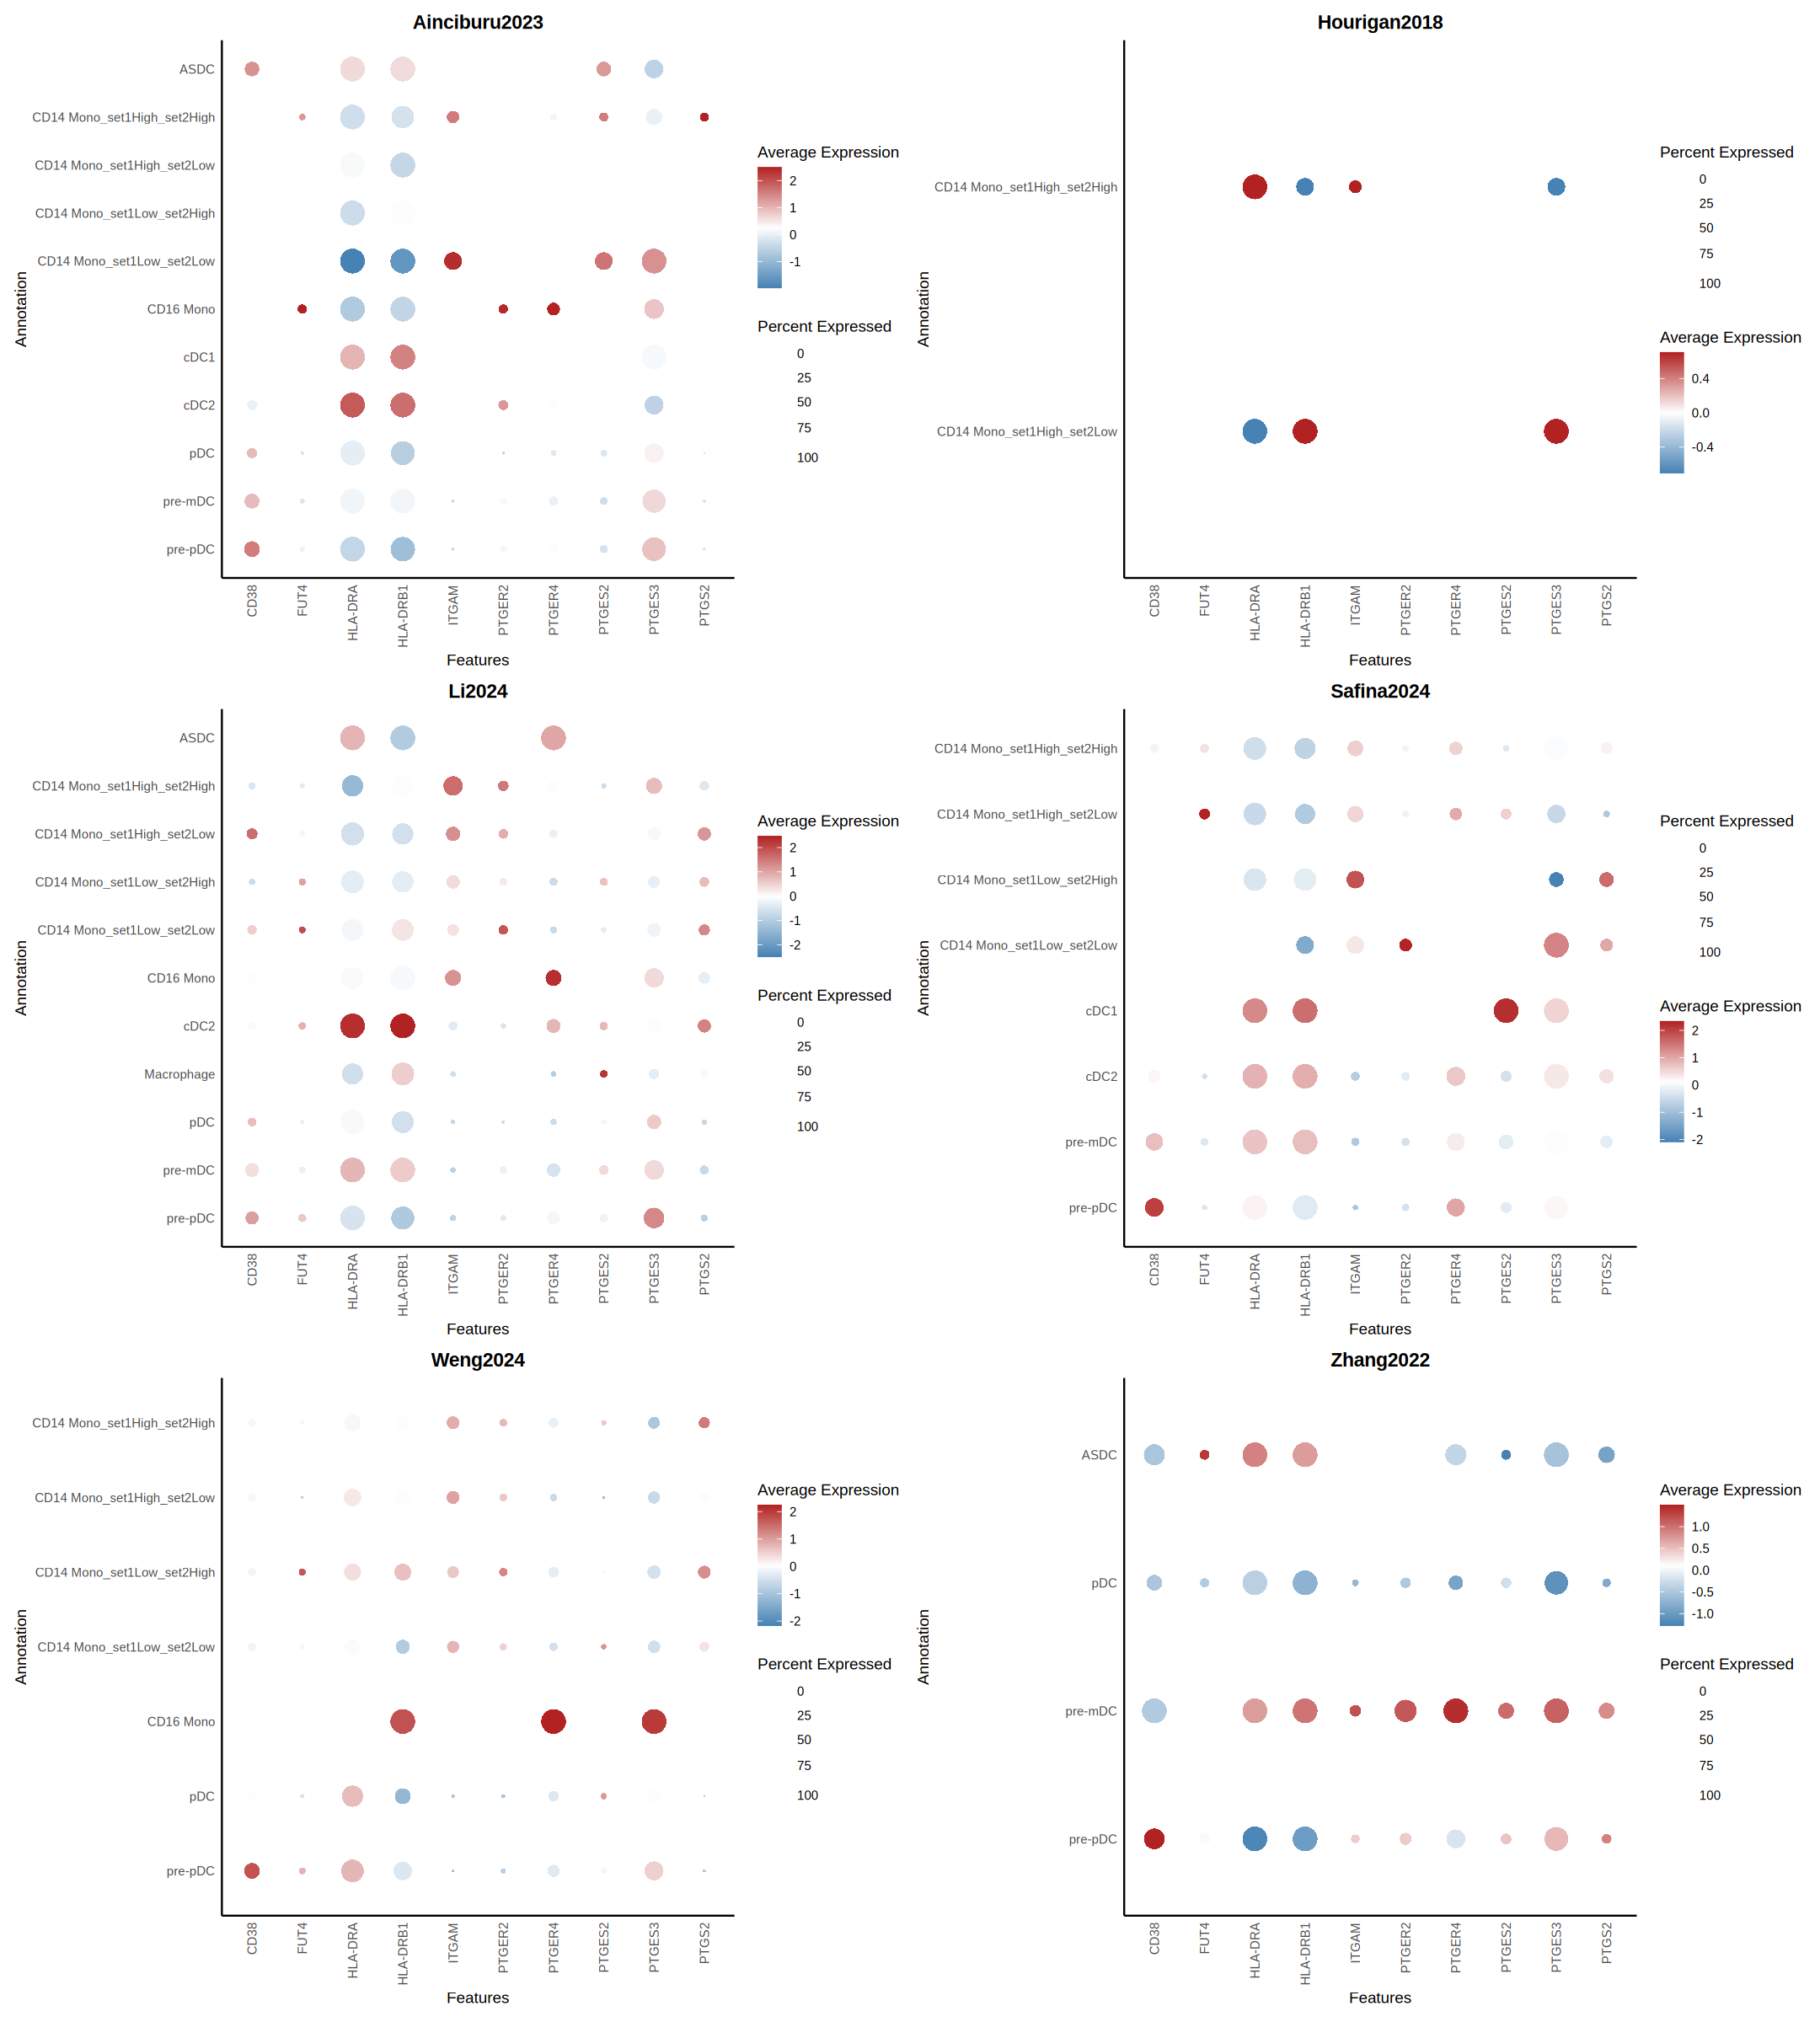

In [39]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(reshape2)
library(pheatmap)
library(RColorBrewer)
library(patchwork)

# ============================================================
# 1) Define targets
# ============================================================

targets <- c(
  "CD14 Mono", "CD16 Mono", "ASDC", "cDC1", "cDC2",
  "Macrophage", "pDC", "pre-mDC", "pre-pDC"
)

# Alphabetical target order
targets <- sort(unique(targets))

Idents(bm_anno_myeloid) <- "final_label"

available <- levels(Idents(bm_anno_myeloid))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in final_label.\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message(
    "These requested identities were NOT found and will be skipped: ",
    paste(missing, collapse = ", ")
  )
}

# ============================================================
# 2) Subset target myeloid/DC cells from original object
# ============================================================

sce1_monodc <- subset(bm_anno_myeloid, idents = keep)

# ============================================================
# 3) Define genes
# ============================================================

allgene <- c(
  "CD38", "ITGAM", "CD14", "FUT4", "HLA-DRA", "HLA-DRB1",
  "PTGS2", "PTGER2", "PTGER4", "PTGES2", "PTGES3"
)

# Alphabetical gene order
allgene <- sort(unique(allgene))

# Optional: keep only genes present in object
genes_found <- allgene[allgene %in% rownames(sce1_monodc)]
genes_missing <- setdiff(allgene, genes_found)

if (length(genes_missing) > 0) {
  message(
    "These requested genes were NOT found and will be skipped: ",
    paste(genes_missing, collapse = ", ")
  )
}

if (length(genes_found) == 0) {
  stop("None of the requested genes are present in the object.")
}

allgene <- genes_found

cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

blue_red_palette <- function(n) {
  colorRampPalette(c("steelblue", "white", "firebrick"))(n)
}

# ============================================================
# 4) Function to make DotPlot
#    - dataset_use = NULL gives non-split plot using all cells
#    - dataset_use = dataset name gives one split plot
# ============================================================

make_annotation_dotplot <- function(obj, dataset_use = NULL, plot_title = NULL) {
  
  if (!is.null(dataset_use)) {
    obj_sub <- subset(obj, subset = Dataset == dataset_use)
  } else {
    obj_sub <- obj
  }
  
  if (ncol(obj_sub) == 0) {
    return(NULL)
  }
  
  Idents(obj_sub) <- "Annotation"
  
  if (length(unique(as.character(Idents(obj_sub)))) < 1) {
    return(NULL)
  }
  
  initial_plot <- DotPlot(
    obj_sub,
    features = allgene,
    scale = TRUE,
    cols = cols_vec
  )
  
  plot_data <- initial_plot$data
  
  # Alphabetical feature order
  plot_data$features.plot <- factor(
    plot_data$features.plot,
    levels = allgene
  )
  
  # Alphabetical Annotation order
  # rev(sort()) displays A-to-Z from top to bottom on ggplot y-axis
  annotation_order <- rev(sort(unique(as.character(plot_data$id))))
  
  plot_data$id <- factor(
    plot_data$id,
    levels = annotation_order
  )
  
  if (is.null(plot_title)) {
    plot_title <- ifelse(is.null(dataset_use), "All datasets", dataset_use)
  }
  
  p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
    geom_point(
      aes(size = pct.exp, fill = avg.exp.scaled),
      shape = 21,
      color = "black",
      stroke = 0
    ) +
    scale_size(range = c(0, 8), name = "Percent Expressed") +
    scale_fill_gradientn(
      colors = blue_red_palette(100),
      name = "Average Expression"
    ) +
    scale_x_discrete(limits = allgene) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.background = element_blank(),
      axis.line = element_line(color = "black"),
      plot.title = element_text(hjust = 0.5, face = "bold")
    ) +
    labs(
      title = plot_title,
      x = "Features",
      y = "Annotation"
    )
  
  return(p)
}

# ============================================================
# 5) Generate non-split and split plots
# ============================================================

# Non-split plot: all datasets pooled
p_all <- make_annotation_dotplot(
  sce1_monodc,
  dataset_use = NULL,
  plot_title = "All datasets"
)

# Split plots: one plot per Dataset
datasets_use <- sort(unique(as.character(sce1_monodc$Dataset)))

plot_list <- lapply(datasets_use, function(ds) {
  make_annotation_dotplot(
    sce1_monodc,
    dataset_use = ds,
    plot_title = ds
  )
})

names(plot_list) <- datasets_use
plot_list <- plot_list[!sapply(plot_list, is.null)]

# Combined split page
p_split_combined <- wrap_plots(plot_list, ncol = 2)

# ============================================================
# 6) Save non-split and split plots to the same PDF
# ============================================================

out_pdf <- "myeloid_DC_dotplot_split_and_nonsplit.pdf"

pdf(out_pdf, width = 6, height = 6)

# Page 1: non-split / pooled plot
print(p_all)

# Page 2: split plots combined
print(p_split_combined)

# Optional: one Dataset per page for easier inspection
for (nm in names(plot_list)) {
  print(plot_list[[nm]])
}

dev.off()

message("Saved PDF: ", out_pdf)

# Show in notebook/RStudio
p_all
options(repr.plot.height = 20, repr.plot.width = 18)
p_split_combined